In [6]:
import json
import numpy as np
import os
import pickle as pkl
from copy import deepcopy
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

In [7]:
# retrieve sample number
cnts = []
cnts_sum = {'normal':0,'jigsaw1':0,'jigsaw2':0,'jigsaw3':0,
                     'blur1':0,'blur2':0,'blur3':0,'blur4':0,'blur5':0,
                     'amount1':0, 'amount2':0,'amount3':0,'amount4':0,'amount5':0}
for rule_no in [0,2,4]:
    image_dir = '../fribble_v2/split_for_models/rule_{}.pkl'.format(rule_no)
    with open(image_dir,'rb') as f:
        imgs = pkl.load(f)

    cnt = {'normal':0,'jigsaw1':0,'jigsaw2':0,'jigsaw3':0,
                     'blur1':0,'blur2':0,'blur3':0,'blur4':0,'blur5':0,
                     'amount1':0, 'amount2':0,'amount3':0,'amount4':0,'amount5':0}
    for img in imgs['test']:
    #     print(img)
        cond = img.split('/')[2].split('_')[-1]
        cond = 'normal' if cond[-1] == '0' else cond 
        cnt[cond] += 1
        cnts_sum[cond] += 1
    cnts.append(cnt)


In [5]:
# # vicreg = ["normal1: 0.3960191011428833	jigsaw1: 0.29164451360702515	jigsaw2: 0.2571181058883667	jigsaw3: 0.32817542552948	blur1: 0.40179046988487244	blur2: 0.3823961615562439	blur3: 0.3810867369174957	blur4: 0.2548854947090149	blur5: 0.20797058939933777	amount1: 0.274280309677124	amount2: 0.2620479464530945	amount3: 0.3584255576133728	amount4: 0.36943256855010986	amount5: 0.41439294815063477",
# #          "normal1: 0.5408338904380798	jigsaw1: 0.38890090584754944	jigsaw2: 0.3373151421546936	jigsaw3: 0.2050359696149826	blur1: 0.5509283542633057	blur2: 0.5233876705169678	blur3: 0.44974780082702637	blur4: 0.29565876722335815	blur5: 0.20875459909439087	amount1: 0.44745853543281555	amount2: 0.49910062551498413	amount3: 0.5414642095565796	amount4: 0.5698654651641846	amount5: 0.7771440744400024",
# #          "normal1: 0.386364221572876	jigsaw1: 0.23883497714996338	jigsaw2: 0.2417387068271637	jigsaw3: 0.38071104884147644	blur1: 0.35952749848365784	blur2: 0.3671882152557373	blur3: 0.36185017228126526	blur4: 0.2947131395339966	blur5: 0.25212472677230835	amount1: 0.3079372048377991	amount2: 0.3475661873817444	amount3: 0.40303683280944824	amount4: 0.4376174807548523	amount5: 0.34663739800453186"]
# # seco = ["normal1: 0.4294244050979614	jigsaw1: 0.3680632412433624	jigsaw2: 0.33547013998031616	jigsaw3: 0.34275439381599426	blur1: 0.4125346541404724	blur2: 0.40652576088905334	blur3: 0.42072412371635437	blur4: 0.32398998737335205	blur5: 0.3110921382904053	amount1: 0.3281081020832062	amount2: 0.3564521074295044	amount3: 0.30954205989837646	amount4: 0.38219350576400757	amount5: 0.3847380578517914",
# #                 "normal1: 0.575452446937561	jigsaw1: 0.4328611493110657	jigsaw2: 0.35507869720458984	jigsaw3: 0.11016476899385452	blur1: 0.5435380935668945	blur2: 0.5060440301895142	blur3: 0.3742679953575134	blur4: 0.2706887722015381	blur5: 0.2741447389125824	amount1: 0.3823000192642212	amount2: 0.40926775336265564	amount3: 0.5105430483818054	amount4: 0.47718188166618347	amount5: 0.6942209005355835",
# #               "normal1: 0.4588196277618408	jigsaw1: 0.41267162561416626	jigsaw2: 0.2864427864551544	jigsaw3: 0.2068318873643875	blur1: 0.4491279423236847	blur2: 0.472148597240448	blur3: 0.3660522699356079	blur4: 0.2687351107597351	blur5: 0.3103329539299011	amount1: 0.459650456905365	amount2: 0.4778657555580139	amount3: 0.5343620181083679	amount4: 0.5431743264198303	amount5: 0.38289475440979004"]

# # seco_small = ["normal1: 0.29758715629577637	jigsaw1: 0.23454539477825165	jigsaw2: 0.23812222480773926	jigsaw3: 0.1985175460577011	blur1: 0.2766803503036499	blur2: 0.2108006775379181	blur3: 0.26221659779548645	blur4: 0.29163864254951477	blur5: 0.2721802592277527	amount1: 0.2801210284233093	amount2: 0.3007804751396179	amount3: 0.3265460729598999	amount4: 0.3608439564704895	amount5: 0.3277554214000702",
# #              "normal1: 0.48616325855255127	jigsaw1: 0.464032918214798	jigsaw2: 0.40972620248794556	jigsaw3: 0.471060574054718	blur1: 0.46612808108329773	blur2: 0.3682807683944702	blur3: 0.28605780005455017	blur4: 0.24333152174949646	blur5: 0.24330908060073853	amount1: 0.27374523878097534	amount2: 0.37114179134368896	amount3: 0.41219401359558105	amount4: 0.42975345253944397	amount5: 0.6343004703521729",
# #              "normal1: 0.44815585017204285	jigsaw1: 0.4232427775859833	jigsaw2: 0.38222986459732056	jigsaw3: 0.440165251493454	blur1: 0.42006930708885193	blur2: 0.34547626972198486	blur3: 0.2706611752510071	blur4: 0.264519065618515	blur5: 0.3017009198665619	amount1: 0.394661009311676	amount2: 0.4861755967140198	amount3: 0.5150393843650818	amount4: 0.5010826587677002	amount5: 0.38596490025520325"]

# # dino = ["normal1: 0.3541146218776703	jigsaw1: 0.3013358414173126	jigsaw2: 0.2707829177379608	jigsaw3: 0.3362010717391968	blur1: 0.37955185770988464	blur2: 0.3788480758666992	blur3: 0.376403272151947	blur4: 0.3707830607891083	blur5: 0.3227626383304596	amount1: 0.23721177875995636	amount2: 0.2614205479621887	amount3: 0.32957592606544495	amount4: 0.37810996174812317	amount5: 0.4424922466278076",
# #        "normal1: 0.45815008878707886	jigsaw1: 0.3229139447212219	jigsaw2: 0.24568971991539001	jigsaw3: 0.19921095669269562	blur1: 0.44165468215942383	blur2: 0.41088730096817017	blur3: 0.3969486355781555	blur4: 0.24475491046905518	blur5: 0.17457929253578186	amount1: 0.439820796251297	amount2: 0.4321996569633484	amount3: 0.49807727336883545	amount4: 0.4795626997947693	amount5: 0.5333680510520935",
# #        "normal1: 0.32822075486183167	jigsaw1: 0.22887441515922546	jigsaw2: 0.24322746694087982	jigsaw3: 0.28336581587791443	blur1: 0.3174414038658142	blur2: 0.32626914978027344	blur3: 0.28837788105010986	blur4: 0.3017055094242096	blur5: 0.26092085242271423	amount1: 0.31661760807037354	amount2: 0.33678483963012695	amount3: 0.28571203351020813	amount4: 0.32605159282684326	amount5: 0.3820175230503082"]
# # orl = ["normal1: 0.4358597993850708	jigsaw1: 0.3641809821128845	jigsaw2: 0.3130044937133789	jigsaw3: 0.1369122862815857	blur1: 0.43655067682266235	blur2: 0.4343975782394409	blur3: 0.46913039684295654	blur4: 0.3487411141395569	blur5: 0.25581908226013184	amount1: 0.2654253840446472	amount2: 0.30400949716567993	amount3: 0.3403940796852112	amount4: 0.3977360427379608	amount5: 0.33208274841308594",
# #       "normal1: 0.5164591670036316	jigsaw1: 0.365756630897522	jigsaw2: 0.29742446541786194	jigsaw3: 0.03126015514135361	blur1: 0.5123323798179626	blur2: 0.5127154588699341	blur3: 0.4630734920501709	blur4: 0.281941682100296	blur5: 0.13218003511428833	amount1: 0.2574039697647095	amount2: 0.3600768744945526	amount3: 0.4726274311542511	amount4: 0.5206872820854187	amount5: 0.4325302839279175",
# #       "normal1: 0.4386311173439026	jigsaw1: 0.34291791915893555	jigsaw2: 0.32167214155197144	jigsaw3: 0.22606515884399414	blur1: 0.43051308393478394	blur2: 0.45088672637939453	blur3: 0.38259217143058777	blur4: 0.2636342942714691	blur5: 0.25144508481025696	amount1: 0.35994774103164673	amount2: 0.39388465881347656	amount3: 0.41246283054351807	amount4: 0.4361498951911926	amount5: 0.38757309317588806"]
# # supervised = ["normal1: 0.34248843789100647	jigsaw1: 0.28981131315231323	jigsaw2: 0.2718903422355652	jigsaw3: 0.303481787443161	blur1: 0.32461297512054443	blur2: 0.31877070665359497	blur3: 0.3130168616771698	blur4: 0.28313660621643066	blur5: 0.25988060235977173	amount1: 0.2805674076080322	amount2: 0.29388436675071716	amount3: 0.3292083144187927	amount4: 0.34882912039756775	amount5: 0.42384299635887146",
# #              "normal1: 0.37655216455459595	jigsaw1: 0.28966444730758667	jigsaw2: 0.26984915137290955	jigsaw3: 0.04130888730287552	blur1: 0.3697727620601654	blur2: 0.37529870867729187	blur3: 0.32048168778419495	blur4: 0.2027609646320343	blur5: 0.21554191410541534	amount1: 0.4220648407936096	amount2: 0.4425221383571625	amount3: 0.41379019618034363	amount4: 0.4311330318450928	amount5: 0.4524564743041992",
# #              "normal1: 0.3529934883117676	jigsaw1: 0.28034543991088867	jigsaw2: 0.24713930487632751	jigsaw3: 0.3774621784687042	blur1: 0.3310393691062927	blur2: 0.38570475578308105	blur3: 0.34048911929130554	blur4: 0.28454330563545227	blur5: 0.28029000759124756	amount1: 0.3049750328063965	amount2: 0.32593560218811035	amount3: 0.35502058267593384	amount4: 0.3421027362346649	amount5: 0.31606099009513855"]

# # simclr = ['normal1: 0.2715176045894623	jigsaw1: 0.25244587659835815	jigsaw2: 0.2603742182254791	jigsaw3: 0.32920041680336	blur1: 0.2866096794605255	blur2: 0.26886409521102905	blur3: 0.27481192350387573	blur4: 0.21943333745002747	blur5: 0.24783824384212494	amount1: 0.25834476947784424	amount2: 0.31565380096435547	amount3: 0.37059885263442993	amount4: 0.3636622428894043	amount5: 0.32955917716026306',
# #          'normal1: 0.4471886157989502	jigsaw1: 0.3688288927078247	jigsaw2: 0.31440022587776184	jigsaw3: 0.16187050938606262	blur1: 0.45654797554016113	blur2: 0.46124526858329773	blur3: 0.3983895778656006	blur4: 0.23048271238803864	blur5: 0.2207687795162201	amount1: 0.44303202629089355	amount2: 0.5160928964614868	amount3: 0.5255662798881531	amount4: 0.5434585809707642	amount5: 0.6742711067199707',
# #          'normal1: 0.3397448658943176	jigsaw1: 0.2889050841331482	jigsaw2: 0.2683943212032318	jigsaw3: 0.27459388971328735	blur1: 0.3450331687927246	blur2: 0.355903297662735	blur3: 0.3205503821372986	blur4: 0.2537313401699066	blur5: 0.2429245263338089	amount1: 0.3832113742828369	amount2: 0.3865499496459961	amount3: 0.41275766491889954	amount4: 0.39920786023139954	amount5: 0.3931286334991455']

# # simsiam = ["normal1: 0.4697895050048828	jigsaw1: 0.3470141887664795	jigsaw2: 0.33670809864997864	jigsaw3: 0.18362011015415192	blur1: 0.4848271906375885	blur2: 0.4249718189239502	blur3: 0.4845519959926605	blur4: 0.29486364126205444	blur5: 0.24799999594688416	amount1: 0.27771204710006714	amount2: 0.355987012386322	amount3: 0.3942524194717407	amount4: 0.4163094758987427	amount5: 0.4257712662220001",
# #         "normal1: 0.5241657495498657	jigsaw1: 0.3310087025165558	jigsaw2: 0.29605671763420105	jigsaw3: 0.12230215966701508	blur1: 0.5272359848022461	blur2: 0.5102187395095825	blur3: 0.4576377868652344	blur4: 0.25529125332832336	blur5: 0.12715008854866028	amount1: 0.41159963607788086	amount2: 0.46297523379325867	amount3: 0.5879407525062561	amount4: 0.6271931529045105	amount5: 0.741906464099884",
# #         "normal1: 0.40119609236717224	jigsaw1: 0.28251972794532776	jigsaw2: 0.2990610897541046	jigsaw3: 0.1873944252729416	blur1: 0.40636810660362244	blur2: 0.4582129418849945	blur3: 0.37758877873420715	blur4: 0.2989879250526428	blur5: 0.24581469595432281	amount1: 0.3613549470901489	amount2: 0.388592392206192	amount3: 0.40293484926223755	amount4: 0.4253503680229187	amount5: 0.3735380172729492"]

# # context_encoder = ["normal1: 0.2980007529258728	jigsaw1: 0.29840677976608276	jigsaw2: 0.23496951162815094	jigsaw3: 0.15090081095695496	blur1: 0.29199889302253723	blur2: 0.27117589116096497	blur3: 0.3087778091430664	blur4: 0.30391061305999756	blur5: 0.25078654289245605	amount1: 0.23907870054244995	amount2: 0.27572256326675415	amount3: 0.3336406946182251	amount4: 0.36942023038864136	amount5: 0.2154477834701538",
# #                   "normal1: 0.21631649136543274	jigsaw1: 0.2504045069217682	jigsaw2: 0.24285928905010223	jigsaw3: 0.053956832736730576	blur1: 0.21285679936408997	blur2: 0.22077716886997223	blur3: 0.23407144844532013	blur4: 0.22398808598518372	blur5: 0.2528960704803467	amount1: 0.31869056820869446	amount2: 0.28748464584350586	amount3: 0.25908157229423523	amount4: 0.2900051772594452	amount5: 0.1327858716249466",
# #                   "normal1: 0.24112239480018616	jigsaw1: 0.22158755362033844	jigsaw2: 0.2761717140674591	jigsaw3: 0.25588974356651306	blur1: 0.23589415848255157	blur2: 0.2597731649875641	blur3: 0.23000916838645935	blur4: 0.23138582706451416	blur5: 0.2114698588848114	amount1: 0.3169458508491516	amount2: 0.2884741425514221	amount3: 0.30868449807167053	amount4: 0.2828025221824646	amount5: 0.2580200731754303"]

# models = [vicreg, seco, dino, orl, supervised,simclr,simsiam,context_encoder]
# model_names = ['vicreg', 'seco', 'dino', 'orl', 'supervised','simclr','simsiam','context_encoder']
# model_results_all_rules = []
# for rule_no in range(3):
#     model_results = {}
#     for i, model in enumerate(models):
#         model_results[model_names[i]] = {}
#         for entry in model[rule_no].split('\t'):
#             cond, acc1 = entry.split(':')[0], float(entry.split(':')[1].strip())
#             cond = cond.replace('normal1','normal')
#             model_results[model_names[i]][cond] = acc1
#     model_results_all_rules.append(model_results)

In [8]:
root = '/home/liuxiao/ContextReasoning/fribble_exp_0shot_logs/multiruns'
model_names = ['vicreg', 'seco', 'dino', 'orl', 'supervised','simclr','simsiam','context_encoder']

model_results_per_rule = {_:{} for _ in [0,2,4]}
errorbars_per_rule = {_:{} for _ in [0,2,4]}

for rule_no in [0,2,4]:
    model_results = {}
    model_results_all_rules = []
    model_error_bars_all = {k: {} for k in model_names}
    model_error_cnt = {k: {} for k in model_names}
    model_error_bars_all_over_subcond = {k: {} for k in model_names}
    model_error_cnt_over_subcond = {k: {} for k in model_names}
    for model in model_names:
        if model in ['orl']:
            runs = [0,1,3]
        else:
            runs = [0,2,4]
        model_results[model] = {}
        for run_no in runs:
            with open('{}/{}/{}_{}.pkl'.format(root,model,rule_no,run_no),'rb') as f:
                results_tmp = pkl.load(f)
            
            for entry in results_tmp[0].split('\t'):
                cond, acc1 = entry.split(':')[0], float(entry.split(':')[1].strip())
                cond = cond.replace('normal1','normal')
#                 print(model,rule_no,run_no,cond,acc1)
                model_results[model][cond] =  model_results[model].get(cond, 0) + acc1 * (1/3)
            for pth, pred in results_tmp[1].items():
                gt = {'fa1':0,'fb1':1,'fb3':2,'fc1':3}[pth.split('/')[0].split('_')[1]]
                tmp = pth.split('/')[2].split('_') 
                cond = tmp[-1] if len(tmp) == 7 else 'normal'
                model_error_cnt[model].setdefault(cond,[]).append(1 if gt == pred else 0)
                model_error_cnt_over_subcond[model].setdefault(cond[:-1],[]).append(1 if gt == pred else 0)

    model_results_all_rules = model_results
    print(model_results)
    for m,_ in model_error_cnt.items():
        for k,v in _.items():
            model_error_bars_all[m][k] = np.std(v)/(len(v)**0.5)

    for m,_ in model_error_cnt_over_subcond.items():
        for k,v in _.items():
            model_error_bars_all_over_subcond[m][k] = np.std(v)/(len(v)**0.5)

    model_results_per_rule[rule_no] = model_results_all_rules
    errorbars_per_rule[rule_no] = model_error_bars_all

{'vicreg': {'normal': 0.40005034208297724, 'jigsaw1': 0.3062765896320343, 'jigsaw2': 0.26358412702878314, 'jigsaw3': 0.3270508348941803, 'blur1': 0.40984765688578284, 'blur2': 0.38888203104337055, 'blur3': 0.3844927450021108, 'blur4': 0.25650117794672644, 'blur5': 0.21278498073418933, 'amount1': 0.2700340151786804, 'amount2': 0.26134955883026123, 'amount3': 0.36433519919713336, 'amount4': 0.3631538152694702, 'amount5': 0.4219661056995392}, 'seco': {'normal': 0.43577038248380023, 'jigsaw1': 0.3548093239466349, 'jigsaw2': 0.3301205237706502, 'jigsaw3': 0.34987606604894, 'blur1': 0.4215601086616516, 'blur2': 0.4083225826422373, 'blur3': 0.38935961325963336, 'blur4': 0.3030960261821747, 'blur5': 0.2957248389720917, 'amount1': 0.34236909945805866, 'amount2': 0.37231493989626563, 'amount3': 0.3417636652787526, 'amount4': 0.3948477109273274, 'amount5': 0.41399658719698584}, 'dino': {'normal': 0.3473552266756693, 'jigsaw1': 0.30655327439308167, 'jigsaw2': 0.26654939850171405, 'jigsaw3': 0.3363

In [11]:
model_results_all_rules

{'vicreg': {'normal': 0.3863835632801056,
  'jigsaw1': 0.24668575326601663,
  'jigsaw2': 0.23928172886371613,
  'jigsaw3': 0.3692533771197001,
  'blur1': 0.3673728406429291,
  'blur2': 0.36858150362968445,
  'blur3': 0.3590747813383738,
  'blur4': 0.2904726564884186,
  'blur5': 0.2503894567489624,
  'amount1': 0.3152315616607666,
  'amount2': 0.3439988295237223,
  'amount3': 0.41365014513333637,
  'amount4': 0.43807318806648254,
  'amount5': 0.3603731493155161},
 'seco': {'normal': 0.4548950095971425,
  'jigsaw1': 0.3768625557422638,
  'jigsaw2': 0.27571340401967365,
  'jigsaw3': 0.24030136565367377,
  'blur1': 0.4389073053995768,
  'blur2': 0.4541351695855458,
  'blur3': 0.3486827810605367,
  'blur4': 0.2596702675024668,
  'blur5': 0.28324559330940247,
  'amount1': 0.43539391954739887,
  'amount2': 0.46647521853446955,
  'amount3': 0.5132120251655579,
  'amount4': 0.5441275238990784,
  'amount5': 0.39371347427368164},
 'dino': {'normal': 0.3220436175664266,
  'jigsaw1': 0.230794643362

In [6]:
model_results_per_rule

{0: [{'vicreg': {'normal': 0.40005034208297724,
    'jigsaw1': 0.3062765896320343,
    'jigsaw2': 0.26358412702878314,
    'jigsaw3': 0.3270508348941803,
    'blur1': 0.40984765688578284,
    'blur2': 0.38888203104337055,
    'blur3': 0.3844927450021108,
    'blur4': 0.25650117794672644,
    'blur5': 0.21278498073418933,
    'amount1': 0.2700340151786804,
    'amount2': 0.26134955883026123,
    'amount3': 0.36433519919713336,
    'amount4': 0.3631538152694702,
    'amount5': 0.4219661056995392},
   'seco': {'normal': 0.43577038248380023,
    'jigsaw1': 0.3548093239466349,
    'jigsaw2': 0.3301205237706502,
    'jigsaw3': 0.34987606604894,
    'blur1': 0.4215601086616516,
    'blur2': 0.4083225826422373,
    'blur3': 0.38935961325963336,
    'blur4': 0.3030960261821747,
    'blur5': 0.2957248389720917,
    'amount1': 0.34236909945805866,
    'amount2': 0.37231493989626563,
    'amount3': 0.3417636652787526,
    'amount4': 0.3948477109273274,
    'amount5': 0.41399658719698584},
   'dino

In [7]:
model_error_bars_all

{'vicreg': {'amount1': 0.01110013415892935,
  'normal': 0.011045474669892922,
  'blur4': 0.010445510615804256,
  'blur1': 0.011553428065384104,
  'amount4': 0.011992150222644871,
  'amount2': 0.010988082522265075,
  'jigsaw2': 0.010046544052126797,
  'blur3': 0.011271744078841824,
  'jigsaw1': 0.010050762464454181,
  'blur2': 0.011766674608832824,
  'blur5': 0.010238730566426373,
  'amount3': 0.011930373701019667,
  'amount5': 0.016035334557506394,
  'jigsaw3': 0.014861939996459081},
 'seco': {'amount1': 0.011980690905468978,
  'normal': 0.011248176246344789,
  'blur4': 0.009485558948282733,
  'blur1': 0.011840859232524354,
  'amount4': 0.012011544146230829,
  'amount2': 0.011607664493113987,
  'jigsaw2': 0.010687313004927212,
  'blur3': 0.011248583473508137,
  'jigsaw1': 0.011085543366213943,
  'blur2': 0.01213253018887175,
  'blur5': 0.009978660407749126,
  'amount3': 0.012138258968869147,
  'amount5': 0.015870282726712537,
  'jigsaw3': 0.014150485651729793},
 'dino': {'amount1': 0.0

In [5]:
model_error_bars_all_over_subcond

{'vicreg': {'amount': 0.005474258658209075,
  'norma': 0.011045474669892922,
  'blur': 0.00497796034183096,
  'jigsaw': 0.006622357901859412},
 'seco': {'amount': 0.005625157126852471,
  'norma': 0.011248176246344789,
  'blur': 0.005039230341428,
  'jigsaw': 0.00680548727934538},
 'dino': {'amount': 0.005295937961930576,
  'norma': 0.010626131589838482,
  'blur': 0.004905161871786253,
  'jigsaw': 0.006429737255274548},
 'orl': {'amount': 0.005572470394596892,
  'norma': 0.011173013016948312,
  'blur': 0.0049692604495077735,
  'jigsaw': 0.0069149135126357454},
 'supervised': {'amount': 0.005347647642172741,
  'norma': 0.010706628912780966,
  'blur': 0.004958967683261233,
  'jigsaw': 0.006277486826168283},
 'simclr': {'amount': 0.005521351165643969,
  'norma': 0.010688004431502387,
  'blur': 0.004834724309938836,
  'jigsaw': 0.006654834403492215},
 'simsiam': {'amount': 0.005543146977412884,
  'norma': 0.011056444689432331,
  'blur': 0.005045711127354248,
  'jigsaw': 0.006465299486506280

In [13]:
model_results_per_rule

{0: {'vicreg': {'normal': 0.40005034208297724,
   'jigsaw1': 0.3062765896320343,
   'jigsaw2': 0.26358412702878314,
   'jigsaw3': 0.3270508348941803,
   'blur1': 0.40984765688578284,
   'blur2': 0.38888203104337055,
   'blur3': 0.3844927450021108,
   'blur4': 0.25650117794672644,
   'blur5': 0.21278498073418933,
   'amount1': 0.2700340151786804,
   'amount2': 0.26134955883026123,
   'amount3': 0.36433519919713336,
   'amount4': 0.3631538152694702,
   'amount5': 0.4219661056995392},
  'seco': {'normal': 0.43577038248380023,
   'jigsaw1': 0.3548093239466349,
   'jigsaw2': 0.3301205237706502,
   'jigsaw3': 0.34987606604894,
   'blur1': 0.4215601086616516,
   'blur2': 0.4083225826422373,
   'blur3': 0.38935961325963336,
   'blur4': 0.3030960261821747,
   'blur5': 0.2957248389720917,
   'amount1': 0.34236909945805866,
   'amount2': 0.37231493989626563,
   'amount3': 0.3417636652787526,
   'amount4': 0.3948477109273274,
   'amount5': 0.41399658719698584},
  'dino': {'normal': 0.3473552266756

In [16]:
model_results_avg = {}
for rule_no,rule in enumerate([0,2,4]):
    for i, (model_name, results) in enumerate(model_results_per_rule[rule].items()):
        if model_name not in model_results_avg:
            model_results_avg[model_name] = {}
        for cond, acc1 in results.items():
            if cond not in model_results_avg[model_name]:
                model_results_avg[model_name][cond] = 0
            model_results_avg[model_name][cond] += acc1 * cnts[rule_no][cond]


for model_name, results in model_results_avg.items():
    for cond, acc1 in results.items():
        model_results_avg[model_name][cond] = acc1 / cnts_sum[cond]
model_results_avg    

{'vicreg': {'normal': 0.4401866004783911,
  'jigsaw1': 0.31093012859648655,
  'jigsaw2': 0.2791020831337299,
  'jigsaw3': 0.3110024449184554,
  'blur1': 0.43740628334630915,
  'blur2': 0.4260708226434637,
  'blur3': 0.39455050083817444,
  'blur4': 0.27860096676434376,
  'blur5': 0.22520135690768558,
  'amount1': 0.3415080679034045,
  'amount2': 0.3665093187308648,
  'amount3': 0.433968617472675,
  'amount4': 0.4505245886818958,
  'amount5': 0.505734968043509},
 'seco': {'normal': 0.48412211858285426,
  'jigsaw1': 0.38842955388960954,
  'jigsaw2': 0.3186125438501183,
  'jigsaw3': 0.25476411535407845,
  'blur1': 0.4621134861542361,
  'blur2': 0.4550601787318547,
  'blur3': 0.3691499112580251,
  'blur4': 0.27353622667727623,
  'blur5': 0.2808759957188513,
  'amount1': 0.389538192754972,
  'amount2': 0.42234860713973327,
  'amount3': 0.4571549980781213,
  'amount4': 0.4762651013570891,
  'amount5': 0.4883054590509051},
 'dino': {'normal': 0.3746268677026518,
  'jigsaw1': 0.2880122934269022

In [17]:
human_results = {('unsupervised', 0): [['normal1', 0.438, 186, 81],
  ['jigsaw1', 0.497, 60, 28],
  ['jigsaw2', 0.461, 71, 32],
  ['jigsaw3', 0.484, 53, 25],
  ['blur1', 0.349, 34, 13],
  ['blur2', 0.395, 27, 13],
  ['blur3', 0.552, 33, 18],
  ['blur4', 0.265, 42, 11],
  ['blur5', 0.211, 38, 11],
  ['amount1', 0.323, 41, 13],
  ['amount2', 0.469, 38, 18],
  ['amount3', 0.615, 37, 20],
  ['amount4', 0.334, 31, 11],
  ['amount5', 0.459, 29, 14]],
 ('unsupervised', 2): [['normal1', 0.434, 216, 97],
  ['jigsaw1', 0.384, 91, 40],
  ['jigsaw2', 0.378, 76, 36],
  ['jigsaw3', 0.287, 50, 15],
  ['blur1', 0.495, 35, 19],
  ['blur2', 0.413, 36, 19],
  ['blur3', 0.518, 45, 24],
  ['blur4', 0.47, 53, 25],
  ['blur5', 0.312, 39, 12],
  ['amount1', 0.617, 46, 30],
  ['amount2', 0.3, 42, 17],
  ['amount3', 0.4, 40, 17],
  ['amount4', 0.381, 40, 17],
  ['amount5', 0.452, 31, 14]],
 ('unsupervised', 4): [['normal1', 0.421, 175, 80],
  ['jigsaw1', 0.243, 56, 14],
  ['jigsaw2', 0.359, 55, 19],
  ['jigsaw3', 0.299, 51, 17],
  ['blur1', 0.323, 30, 9],
  ['blur2', 0.476, 31, 15],
  ['blur3', 0.344, 32, 11],
  ['blur4', 0.38, 38, 15],
  ['blur5', 0.275, 35, 10],
  ['amount1', 0.275, 34, 12],
  ['amount2', 0.343, 39, 14],
  ['amount3', 0.368, 37, 15],
  ['amount4', 0.246, 36, 9],
  ['amount5', 0.289, 31, 10]],
 ('supervised', 0): [['normal1', 0.443, 165, 72],
  ['jigsaw1', 0.362, 51, 18],
  ['jigsaw2', 0.319, 65, 22],
  ['jigsaw3', 0.255, 48, 12],
  ['blur1', 0.396, 32, 12],
  ['blur2', 0.382, 24, 7],
  ['blur3', 0.31, 28, 9],
  ['blur4', 0.269, 35, 10],
  ['blur5', 0.202, 39, 8],
  ['amount1', 0.239, 34, 8],
  ['amount2', 0.243, 34, 8],
  ['amount3', 0.505, 29, 12],
  ['amount4', 0.451, 27, 12],
  ['amount5', 0.417, 29, 11]],
 ('supervised', 2): [['normal1', 0.483, 188, 93],
  ['jigsaw1', 0.474, 86, 41],
  ['jigsaw2', 0.492, 69, 35],
  ['jigsaw3', 0.378, 43, 17],
  ['blur1', 0.507, 38, 18],
  ['blur2', 0.458, 35, 17],
  ['blur3', 0.488, 45, 23],
  ['blur4', 0.312, 41, 13],
  ['blur5', 0.529, 36, 19],
  ['amount1', 0.412, 43, 19],
  ['amount2', 0.293, 39, 14],
  ['amount3', 0.494, 41, 21],
  ['amount4', 0.493, 31, 15],
  ['amount5', 0.25, 25, 7]],
 ('supervised', 4): [['normal1', 0.38, 172, 71],
  ['jigsaw1', 0.39, 58, 24],
  ['jigsaw2', 0.497, 62, 32],
  ['jigsaw3', 0.314, 48, 16],
  ['blur1', 0.472, 29, 14],
  ['blur2', 0.49, 29, 14],
  ['blur3', 0.439, 30, 14],
  ['blur4', 0.281, 38, 12],
  ['blur5', 0.382, 40, 15],
  ['amount1', 0.183, 33, 7],
  ['amount2', 0.356, 40, 15],
  ['amount3', 0.429, 37, 16],
  ['amount4', 0.471, 33, 17],
  ['amount5', 0.457, 31, 15]]}
human_unsup = {}
human_sup = {}
human_unsup_cnt = {}
human_sup_cnt = {}
human_unsup_error = {}
human_sup_error = {}
human_unsup_cnt_over_subcond = {}
human_unsup_error_over_subcond = {}

# for i, rule_no in enumerate([0,2,4]):
#     for cond in cnts_sum.keys():
#         if cond not in human_unsup:
#             human_unsup[cond] = 0
#         if cond not in human_sup:
#             human_sup[cond] = 0
#         human_unsup[cond] = human_results[("unsupervised",rule_no)]
for k,v in human_results.items():
    if k[1] in [1,3]:
        continue
    for entry in v:
        cond, acc1, cnt, acc_cnt = entry
#         errorbar = np.std([1]*acc_cnt + [0]*(cnt-acc_cnt)) / (cnt**0.5) 
        cond = cond.replace("normal1","normal")
        if k[0] == "unsupervised":
            human_unsup[cond] = human_unsup.get(cond,0) + acc1*cnt
            human_unsup_cnt[cond] = human_unsup_cnt.get(cond,0) + cnt
            human_unsup_cnt_over_subcond[cond[:-1]] = human_unsup_cnt_over_subcond.get(cond[:-1],0) + cnt
            human_unsup_error[cond] = human_unsup_error.get(cond,0) + acc_cnt
            human_unsup_error_over_subcond[cond[:-1]]  = human_unsup_error_over_subcond.get(cond[:-1],0) + acc_cnt
        else:
            human_sup[cond] = human_sup.get(cond,0) + acc1*cnt
            human_sup_cnt[cond] = human_sup_cnt.get(cond,0) + cnt
            human_sup_error[cond] = human_sup_error.get(cond,0) + acc_cnt
            
        
for k,v in human_unsup.items():
    human_unsup[k] = human_unsup[k] / human_unsup_cnt[k]
    human_unsup_error[k] = np.std([1]*human_unsup_error[k] + [0]*(human_unsup_cnt[k]-human_unsup_error[k])) / (human_unsup_cnt[k]**0.5) 

for k,v in human_sup.items():
    human_sup[k] = human_sup[k] / human_sup_cnt[k]
    human_sup_error[k] = np.std([1]*human_sup_error[k] + [0]*(human_sup_cnt[k]-human_sup_error[k])) / (human_sup_cnt[k]**0.5) 

for k,v in human_unsup_error_over_subcond.items():
    human_unsup_error_over_subcond[k] = np.std([1]*v + [0]*(human_unsup_cnt_over_subcond[k]-v)) / (human_unsup_cnt_over_subcond[k]**0.5) 


In [9]:
human_unsup_error_over_subcond

{'norma': 0.02069862396773713,
 'jigsaw': 0.02065887071174324,
 'blur': 0.02101462683610344,
 'amount': 0.02099664423020066}

In [11]:
human_unsup_cnt

{'normal': 577,
 'jigsaw1': 207,
 'jigsaw2': 202,
 'jigsaw3': 154,
 'blur1': 99,
 'blur2': 94,
 'blur3': 110,
 'blur4': 133,
 'blur5': 112,
 'amount1': 121,
 'amount2': 119,
 'amount3': 114,
 'amount4': 107,
 'amount5': 91}

In [9]:
human_sup_error, human_unsup_error

({'normal': 0.02171030715033591,
  'jigsaw1': 0.03540757147280004,
  'jigsaw2': 0.03556335992398089,
  'jigsaw3': 0.03968697369379464,
  'blur1': 0.049940730552832754,
  'blur2': 0.052802294163896875,
  'blur3': 0.048984706091023796,
  'blur4': 0.0432006509476255,
  'blur5': 0.0448992735869577,
  'amount1': 0.04406129191852727,
  'amount2': 0.0441458611460336,
  'amount3': 0.048165532968335374,
  'amount4': 0.05238575153192088,
  'amount5': 0.05286037663383562},
 {'normal': 0.02069862396773713,
  'jigsaw1': 0.03399432440330523,
  'jigsaw2': 0.03484026842250229,
  'jigsaw3': 0.03890829622809868,
  'blur1': 0.049505463756652664,
  'blur2': 0.05157106231293967,
  'blur3': 0.04764159961130258,
  'blur4': 0.042161354302586274,
  'blur5': 0.0430768047335171,
  'amount1': 0.04526632706654265,
  'amount2': 0.045115587579257106,
  'amount3': 0.046648774563061136,
  'amount4': 0.045980555685499344,
  'amount5': 0.0516972741548122})

In [55]:
print(human_unsup)
print(human_sup)

{'normal': 0.43134662045060657, 'jigsaw1': 0.378608695652174, 'jigsaw2': 0.402, 'jigsaw3': 0.3587727272727273, 'blur1': 0.3927373737373737, 'blur2': 0.42860638297872344, 'blur3': 0.4775818181818182, 'blur4': 0.3795488721804511, 'blur5': 0.26616964285714284, 'amount1': 0.4212809917355372, 'amount2': 0.36805882352941177, 'amount3': 0.45939473684210524, 'amount4': 0.32196261682242994, 'amount5': 0.3987032967032967}
{'normal': 0.43668380952380953, 'jigsaw1': 0.4197230769230769, 'jigsaw2': 0.4362091836734694, 'jigsaw3': 0.3134244604316547, 'blur1': 0.4608686868686869, 'blur2': 0.44781818181818184, 'blur3': 0.4253398058252427, 'blur4': 0.2884649122807018, 'blur5': 0.36697391304347826, 'amount1': 0.2898272727272727, 'amount2': 0.3002566371681416, 'amount3': 0.4745046728971962, 'amount4': 0.4725604395604396, 'amount5': 0.3824705882352941}


In [18]:

human_res_names = ['human_sup','human_unsup']
for i,human_result in enumerate([human_sup,human_unsup]):
    model_results_avg[human_res_names[i]] = human_result
for i,human_result in enumerate([human_sup_error,human_unsup_error]):
    model_error_bars_all[human_res_names[i]] = human_result

In [ ]:
# # one run
# {'vicreg': {'normal': 0.4394132202473756,
#   'jigsaw1': 0.3044198713667577,
#   'jigsaw2': 0.27799393706278414,
#   'jigsaw3': 0.3139911088770236,
#   'blur1': 0.4321113572866087,
#   'blur2': 0.42374751060915905,
#   'blur3': 0.39801057646134486,
#   'blur4': 0.28197968088584263,
#   'blur5': 0.2240452709357913,
#   'amount1': 0.33971776598227954,
#   'amount2': 0.3676095878573209,
#   'amount3': 0.4318483439268595,
#   'amount4': 0.4554478812531985,
#   'amount5': 0.4940194048200335},
#  'seco': {'normal': 0.48655081760846197,
#   'jigsaw1': 0.4041940393039015,
#   'jigsaw2': 0.3256062798552279,
#   'jigsaw3': 0.2392733084959555,
#   'blur1': 0.46571406606050014,
#   'blur2': 0.4613789908017553,
#   'blur3': 0.3870260061532554,
#   'blur4': 0.2874548919262735,
#   'blur5': 0.2993302028717064,
#   'amount1': 0.3892359115584882,
#   'amount2': 0.4173263962878737,
#   'amount3': 0.4492333840388322,
#   'amount4': 0.46697719708540397,
#   'amount5': 0.4699402263334819},
#  'dino': {'normal': 0.3788123687386884,
#   'jigsaw1': 0.2831445159189705,
#   'jigsaw2': 0.2535482479068331,
#   'jigsaw3': 0.28413015021378607,
#   'blur1': 0.37614932072568696,
#   'blur2': 0.37173339678197387,
#   'blur3': 0.3544271555385179,
#   'blur4': 0.3059381974705358,
#   'blur5': 0.25450868926397185,
#   'amount1': 0.3272169149118269,
#   'amount2': 0.3424895746976617,
#   'amount3': 0.36863783106438186,
#   'amount4': 0.3920302736752043,
#   'amount5': 0.44901705486433846},
#  'orl': {'normal': 0.462794240978029,
#   'jigsaw1': 0.3573242348159758,
#   'jigsaw2': 0.3108270240899844,
#   'jigsaw3': 0.13911722261445744,
#   'blur1': 0.45751671083362144,
#   'blur2': 0.46574928486746464,
#   'blur3': 0.4386363794215548,
#   'blur4': 0.2974053668185682,
#   'blur5': 0.21580211607421318,
#   'amount1': 0.29467081159888625,
#   'amount2': 0.35439413604668085,
#   'amount3': 0.40681985493718376,
#   'amount4': 0.4493327214019323,
#   'amount5': 0.3770438003540039},
#  'supervised': {'normal': 0.357060554939267,
#   'jigsaw1': 0.28648796114778596,
#   'jigsaw2': 0.2630453348701072,
#   'jigsaw3': 0.2609314196017993,
#   'blur1': 0.3407167696967322,
#   'blur2': 0.359897420006363,
#   'blur3': 0.3245737868349798,
#   'blur4': 0.25768617812426015,
#   'blur5': 0.25340987020512906,
#   'amount1': 0.3329951548290824,
#   'amount2': 0.35220209123054713,
#   'amount3': 0.36488275084640126,
#   'amount4': 0.3722694298155369,
#   'amount5': 0.398514569742339},
#  'simclr': {'normal': 0.3514684020451668,
#   'jigsaw1': 0.30222738598096627,
#   'jigsaw2': 0.28051535304412883,
#   'jigsaw3': 0.26883566464622954,
#   'blur1': 0.35953895580884604,
#   'blur2': 0.36151843630312164,
#   'blur3': 0.33168477048840617,
#   'blur4': 0.23499906518273808,
#   'blur5': 0.2376585531707217,
#   'amount1': 0.35801956789222306,
#   'amount2': 0.4043952483255094,
#   'amount3': 0.434235735735485,
#   'amount4': 0.43205663233263325,
#   'amount5': 0.44470934416566577},
#  'simsiam': {'normal': 0.463887730522443,
#   'jigsaw1': 0.3195798461183882,
#   'jigsaw2': 0.31110006691808373,
#   'jigsaw3': 0.16925630336917397,
#   'blur1': 0.46952392842502777,
#   'blur2': 0.46423770669116926,
#   'blur3': 0.4402830678581706,
#   'blur4': 0.2835339023675286,
#   'blur5': 0.2096351123074206,
#   'amount1': 0.34765994431015973,
#   'amount2': 0.4014433611697502,
#   'amount3': 0.4590064073856322,
#   'amount4': 0.48535898386753556,
#   'amount5': 0.4972681899581637},
#  'context_encoder': {'normal': 0.25223134167159705,
#   'jigsaw1': 0.25648966749864527,
#   'jigsaw2': 0.25114759305316925,
#   'jigsaw3': 0.1604849787744787,
#   'blur1': 0.24762946853092407,
#   'blur2': 0.25073448679984756,
#   'blur3': 0.2575949214446538,
#   'blur4': 0.25274106824088854,
#   'blur5': 0.23734608488838846,
#   'amount1': 0.2901211354190004,
#   'amount2': 0.28406533127962724,
#   'amount3': 0.3014537149887448,
#   'amount4': 0.3149484693825495,
#   'amount5': 0.20567521729639598},
#  'human_sup': {'normal': 0.43668380952380953,
#   'jigsaw1': 0.4197230769230769,
#   'jigsaw2': 0.4362091836734694,
#   'jigsaw3': 0.3134244604316547,
#   'blur1': 0.4608686868686869,
#   'blur2': 0.44781818181818184,
#   'blur3': 0.4253398058252427,
#   'blur4': 0.2884649122807018,
#   'blur5': 0.36697391304347826,
#   'amount1': 0.2898272727272727,
#   'amount2': 0.3002566371681416,
#   'amount3': 0.4745046728971962,
#   'amount4': 0.4725604395604396,
#   'amount5': 0.3824705882352941},
#  'human_unsup': {'normal': 0.43134662045060657,
#   'jigsaw1': 0.378608695652174,
#   'jigsaw2': 0.402,
#   'jigsaw3': 0.3587727272727273,
#   'blur1': 0.3927373737373737,
#   'blur2': 0.42860638297872344,
#   'blur3': 0.4775818181818182,
#   'blur4': 0.3795488721804511,
#   'blur5': 0.26616964285714284,
#   'amount1': 0.4212809917355372,
#   'amount2': 0.36805882352941177,
#   'amount3': 0.45939473684210524,
#   'amount4': 0.32196261682242994,
#   'amount5': 0.3987032967032967}}

In [18]:
model_results_avg

{'vicreg': {'normal': 0.4401866004783911,
  'jigsaw1': 0.31093012859648655,
  'jigsaw2': 0.2791020831337299,
  'jigsaw3': 0.3110024449184554,
  'blur1': 0.43740628334630915,
  'blur2': 0.4260708226434637,
  'blur3': 0.39455050083817444,
  'blur4': 0.27860096676434376,
  'blur5': 0.22520135690768558,
  'amount1': 0.3415080679034045,
  'amount2': 0.3665093187308648,
  'amount3': 0.433968617472675,
  'amount4': 0.4505245886818958,
  'amount5': 0.505734968043509},
 'seco': {'normal': 0.48412211858285426,
  'jigsaw1': 0.38842955388960954,
  'jigsaw2': 0.3186125438501183,
  'jigsaw3': 0.25476411535407845,
  'blur1': 0.4621134861542361,
  'blur2': 0.4550601787318547,
  'blur3': 0.3691499112580251,
  'blur4': 0.27353622667727623,
  'blur5': 0.2808759957188513,
  'amount1': 0.389538192754972,
  'amount2': 0.42234860713973327,
  'amount3': 0.4571549980781213,
  'amount4': 0.4762651013570891,
  'amount5': 0.4883054590509051},
 'dino': {'normal': 0.3746268677026518,
  'jigsaw1': 0.2880122934269022

In [19]:
model_names
model_names = ['supervised','seco_large','vicreg', 'orl']
model_names = ['seco','orl', 'simsiam','vicreg','dino','simclr','context_encoder','supervised']
# model_names = ['seco','orl','vicreg','dino','simsiam','simclr','context-encoder','supervised']

# model_names = ['seco', 'simsiam','vicreg','dino','simclr','context_encoder','supervised']


In [14]:
human_res_names

['human_sup', 'human_unsup']

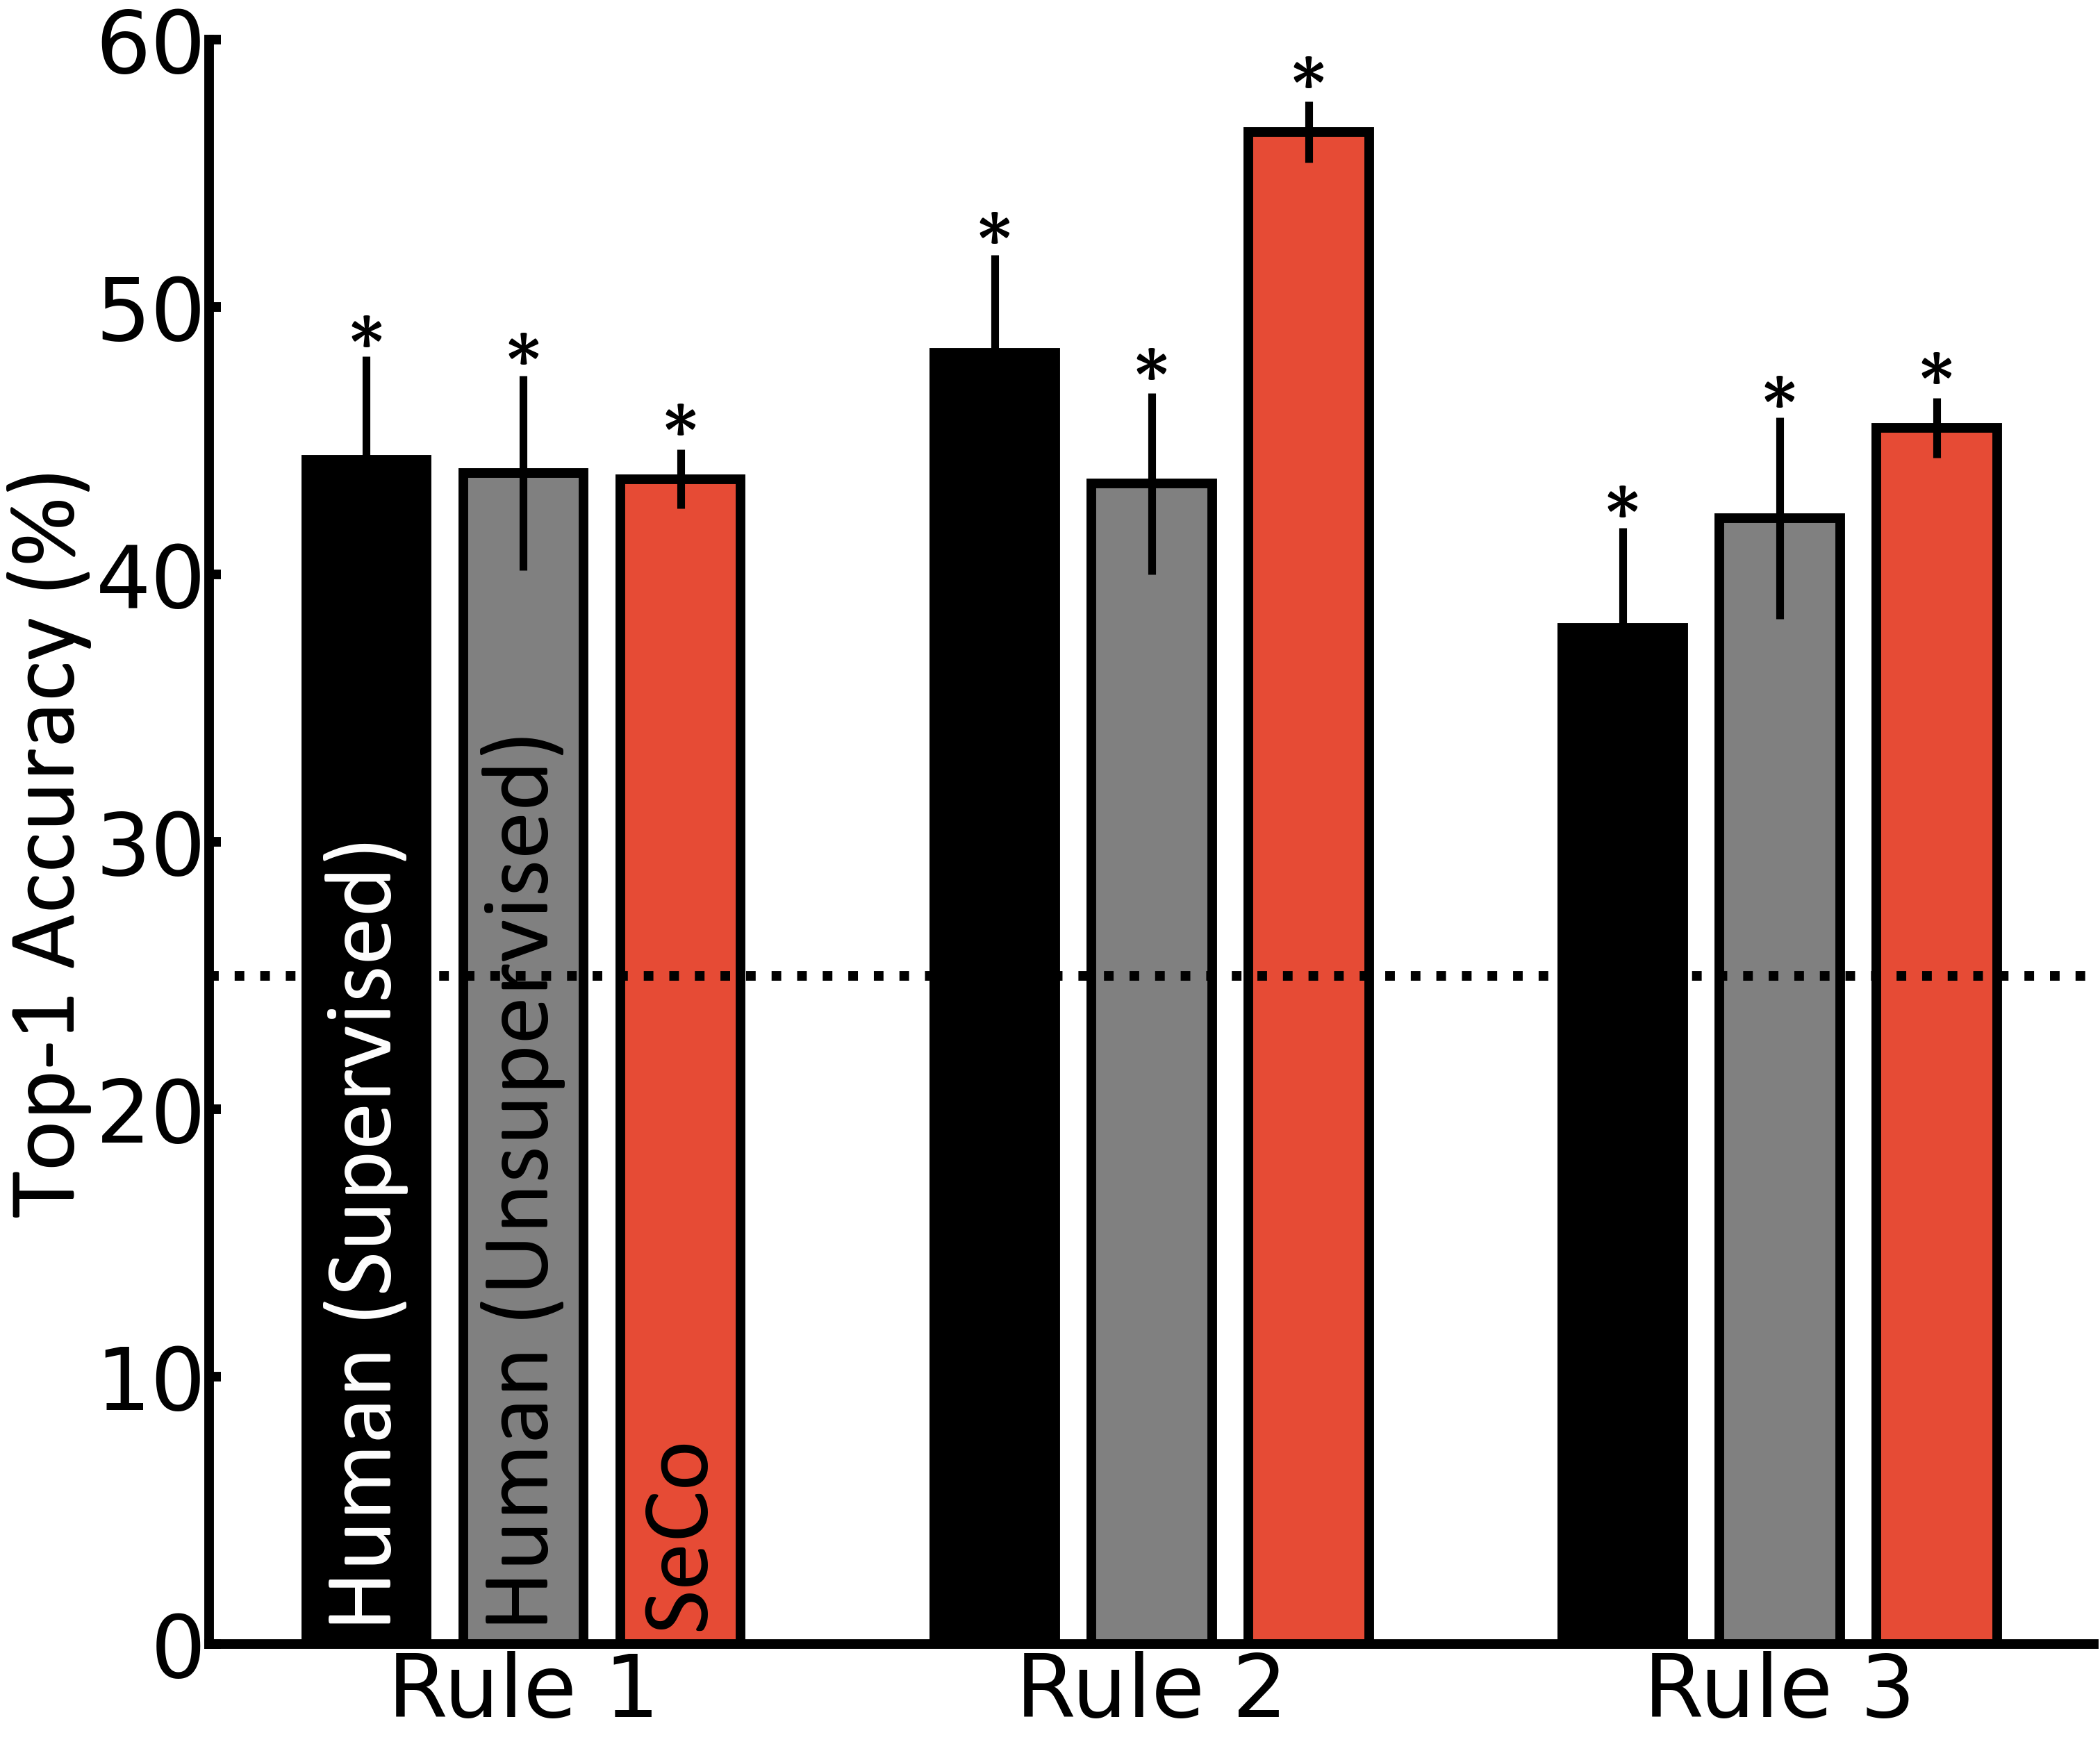

In [20]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

def calculate_std(N,correct):
    return np.std([1]*correct+[0]*(N-correct))/(N**0.5)

fig, ax = plt.subplots(1, 1,figsize=(35,30))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

# fig, ax = plt.subplots(1, 1,figsize=(12,4))

xtick_rename = ['Rule {}'.format(_) for _ in [1,2,3]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, yerr, colors, labels = [], [], [], [], [], []


for i,rule_no in enumerate([0,2,4]):
    ys.append(human_results[('supervised',rule_no)][0][1])
    ys.append(human_results[('unsupervised',rule_no)][0][1])
    ys.append(model_results_per_rule[rule_no]['seco']['normal'])
#     ys.append(model_results_per_rule[rule_no]['orl']['normal'])
#     ys.append(model_results_per_rule[rule_no]['supervised']['normal'])
    xs.extend([i*4+_ for _ in range(3)])
    yerr.append(calculate_std(human_results[('supervised',rule_no)][0][2], human_results[('supervised',rule_no)][0][3]))
    yerr.append(calculate_std(human_results[('unsupervised',rule_no)][0][2], human_results[('unsupervised',rule_no)][0][3]))
    yerr.append(errorbars_per_rule[rule_no]['seco']['normal'])
#     yerr.append(errorbars_per_rule[rule_no]['orl']['normal'])
#     yerr.append(errorbars_per_rule[rule_no]['supervised']['normal'])
    colors.extend(["black","gray","#e64b35"])
    labels.extend(["Human (Supervised)", "Human (Unsupervised)", "SeCo"])
    xtick_ori.append(i*4+1)
plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=10)
# plt.plot([-7.5]+xs+[xs[-1]+7.5], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=12)

# bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
bars =plt.bar(xs,ys, width=10/13,linewidth=10,edgecolor='black',color=colors, label=labels)
plt.errorbar(xs,ys, yerr,elinewidth=8,fmt="o", color='black')

# plt.xlabel('mode', fontsize=18)
plt.ylabel('Top-1 Accuracy (%)', fontsize=100,weight = 'bold',fontproperties=prop)
plt.xticks(xtick_ori,xtick_rename,fontsize=90)
plt.yticks([_*0.01 for _ in range(0,61,10)],range(0,61,10),fontsize=90)
# plt.legend(["chance"],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.25,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
ax.set_xlim([-1, xs[-1]+1])
ax.set_ylim([0, 0.6])

ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(10)
    

for i, rect in enumerate(bars):
    height = rect.get_height()
    color = 'white' if i == 0 else 'black'
    star_height = height + yerr[i]/1.5 if i %3 != 2 else height 
    if i <=2:
        plt.text(rect.get_x() + rect.get_width() / 2.0, 0.005, labels[i], color=color, ha='center', va='bottom',rotation='vertical',fontsize=100,fontproperties=prop)
    plt.text(rect.get_x() + rect.get_width() / 2.0, star_height, '*', color='black', ha='center', va='bottom',fontsize=90,fontproperties=prop)
ax.tick_params(axis='y',direction='in', length=12,width=10)

In [24]:
yerr

[0.0,
 0.0,
 0.0111090674249188,
 0.0,
 0.0,
 0.011433967176809013,
 0.0,
 0.0,
 0.011248176246344789]

In [17]:
model_results_per_rule

{0: [{'vicreg': {'normal': 0.40005034208297724,
    'jigsaw1': 0.3062765896320343,
    'jigsaw2': 0.26358412702878314,
    'jigsaw3': 0.3270508348941803,
    'blur1': 0.40984765688578284,
    'blur2': 0.38888203104337055,
    'blur3': 0.3844927450021108,
    'blur4': 0.25650117794672644,
    'blur5': 0.21278498073418933,
    'amount1': 0.2700340151786804,
    'amount2': 0.26134955883026123,
    'amount3': 0.36433519919713336,
    'amount4': 0.3631538152694702,
    'amount5': 0.4219661056995392},
   'seco': {'normal': 0.43577038248380023,
    'jigsaw1': 0.3548093239466349,
    'jigsaw2': 0.3301205237706502,
    'jigsaw3': 0.34987606604894,
    'blur1': 0.4215601086616516,
    'blur2': 0.4083225826422373,
    'blur3': 0.38935961325963336,
    'blur4': 0.3030960261821747,
    'blur5': 0.2957248389720917,
    'amount1': 0.34236909945805866,
    'amount2': 0.37231493989626563,
    'amount3': 0.3417636652787526,
    'amount4': 0.3948477109273274,
    'amount5': 0.41399658719698584},
   'dino

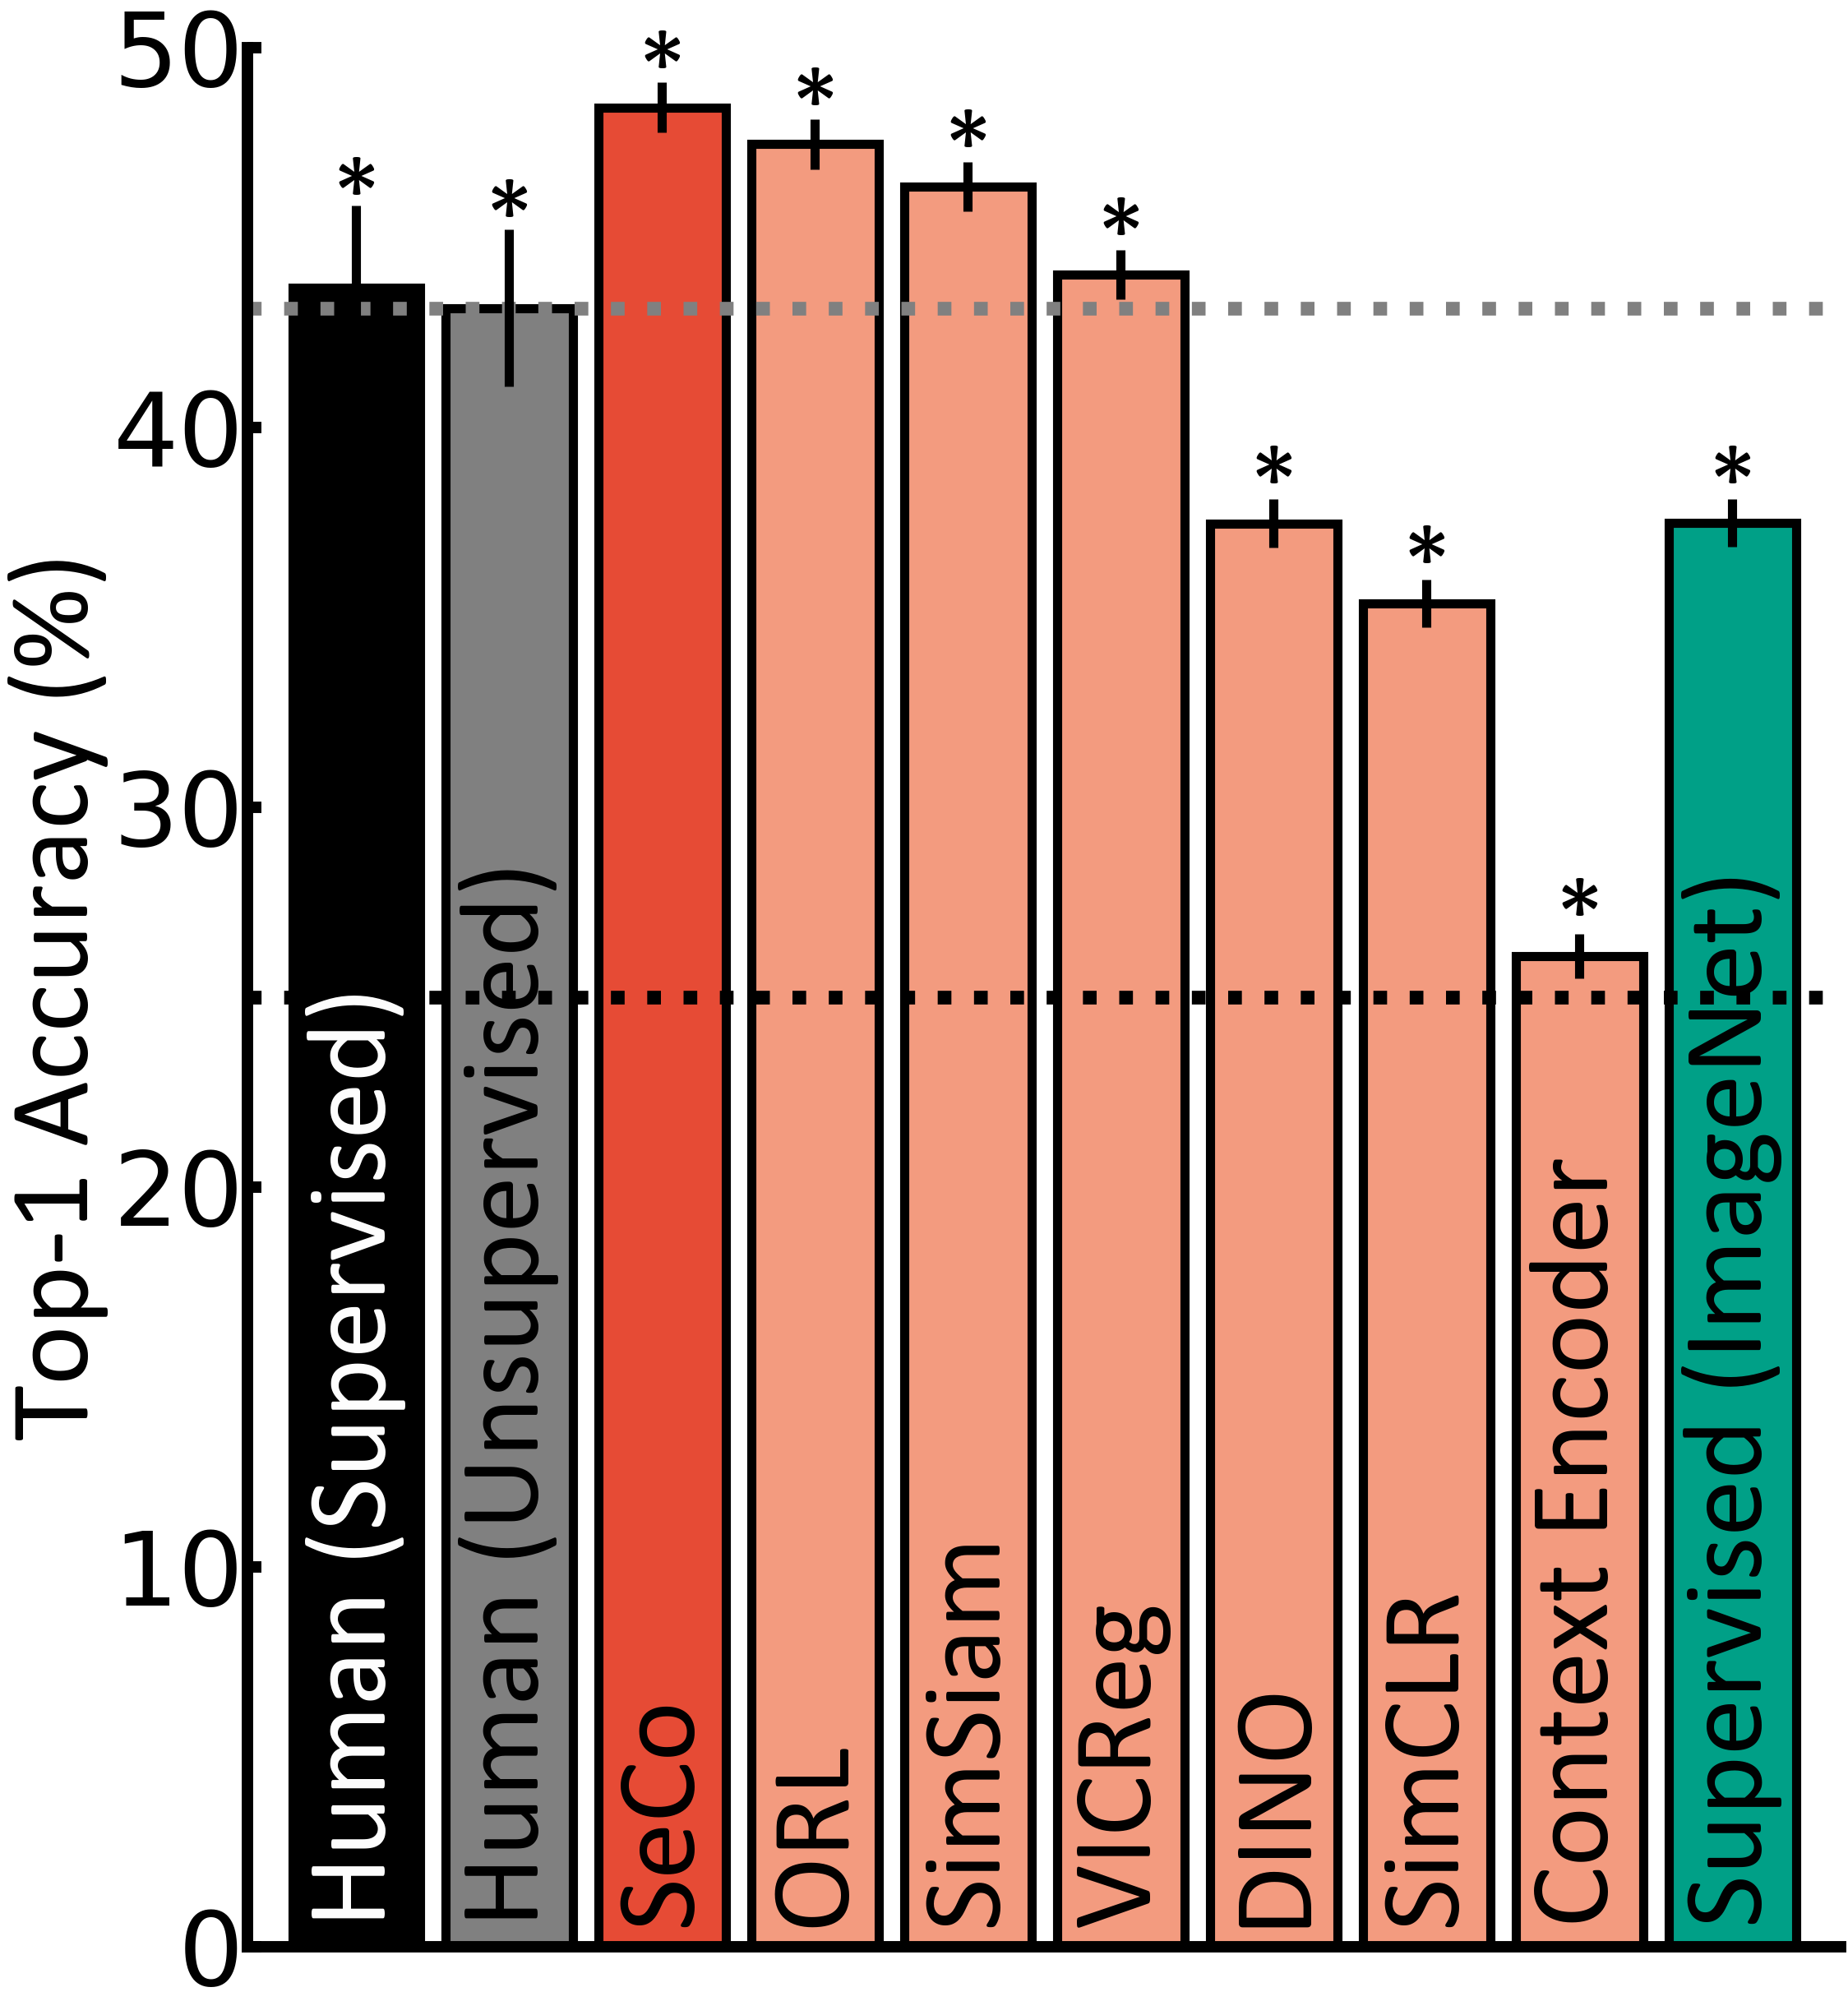

In [24]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
fig, ax = plt.subplots(1, 1,figsize=(25,30))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')
ys = []
yerr = []
plt.rc('font', weight='bold')
# plt.rcParams['text.latex.preamble'] = r'\usepackage{sfmath} \boldmath'

for model in human_res_names + model_names:
    ys.append(model_results_avg[model]['normal'])
    yerr.append(model_error_bars_all[model]['normal'])
xs = [_*(len(model_names)+3)+_ for _ in range(len(model_names)+2)]
colors = ["black","gray","#e64b35","#f39b7f","#f39b7f","#f39b7f","#f39b7f","#f39b7f","#f39b7f","#00a087"]
# labels = human_res_names + model_names
labels = ["Human (Supervised)", "Human (Unsupervised)", "SeCo","ORL","SimSiam",  "VICReg",  "DINO","SimCLR","Context Encoder", "Supervised (ImageNet)"]
# labels = ["Human (Supervised)", "Human (Unsupervised)", "SeCo","SimSiam", "VICReg",  "DINO","SimCLR","Context Encoder", "Supervised (ImageNet)"]

plt.plot([-8.5]+xs+[xs[-1]+8.5], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=12)
plt.plot([-8.5]+xs+[xs[-1]+8.5], [model_results_avg['human_unsup']['normal']]*(len(xs)+2),label='human_unsup',ls=':',color='gray',linewidth=12)

bars =plt.bar(xs,ys, width=10,linewidth=8,edgecolor='black',color=colors, label=labels)
plt.errorbar(xs,ys, yerr,elinewidth=8,fmt="o", color='black')


# plt.xlabel('mode', fontsize=18)
plt.ylabel('Top-1 Accuracy (%)', fontsize=100,weight = 'bold',fontproperties=prop)
plt.xticks(xs,[],fontsize=15)
plt.yticks([_*0.01 for _ in range(0,51,10)],range(0,51,10),fontsize=90)
# plt.legend(["chance"],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.25,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
ax.set_xlim([-8.5, xs[-1]+8.5])
ax.set_ylim([0, 0.5])

ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(10)
    

for i, rect in enumerate(bars):
    height = rect.get_height()
    color = 'white' if i == 0 else 'black'
    star_height = height + yerr[i]/2 if i in [0,1] else height - yerr[i]/2
    plt.text(rect.get_x() + rect.get_width() / 2.0, 0.005, labels[i], color=color, ha='center', va='bottom',rotation='vertical',fontsize=100,fontproperties=prop)
    plt.text(rect.get_x() + rect.get_width() / 2.0, star_height, '*', color='black', ha='center', va='bottom',fontsize=90,fontproperties=prop)
ax.tick_params(axis='y',direction='in', length=12,width=10)

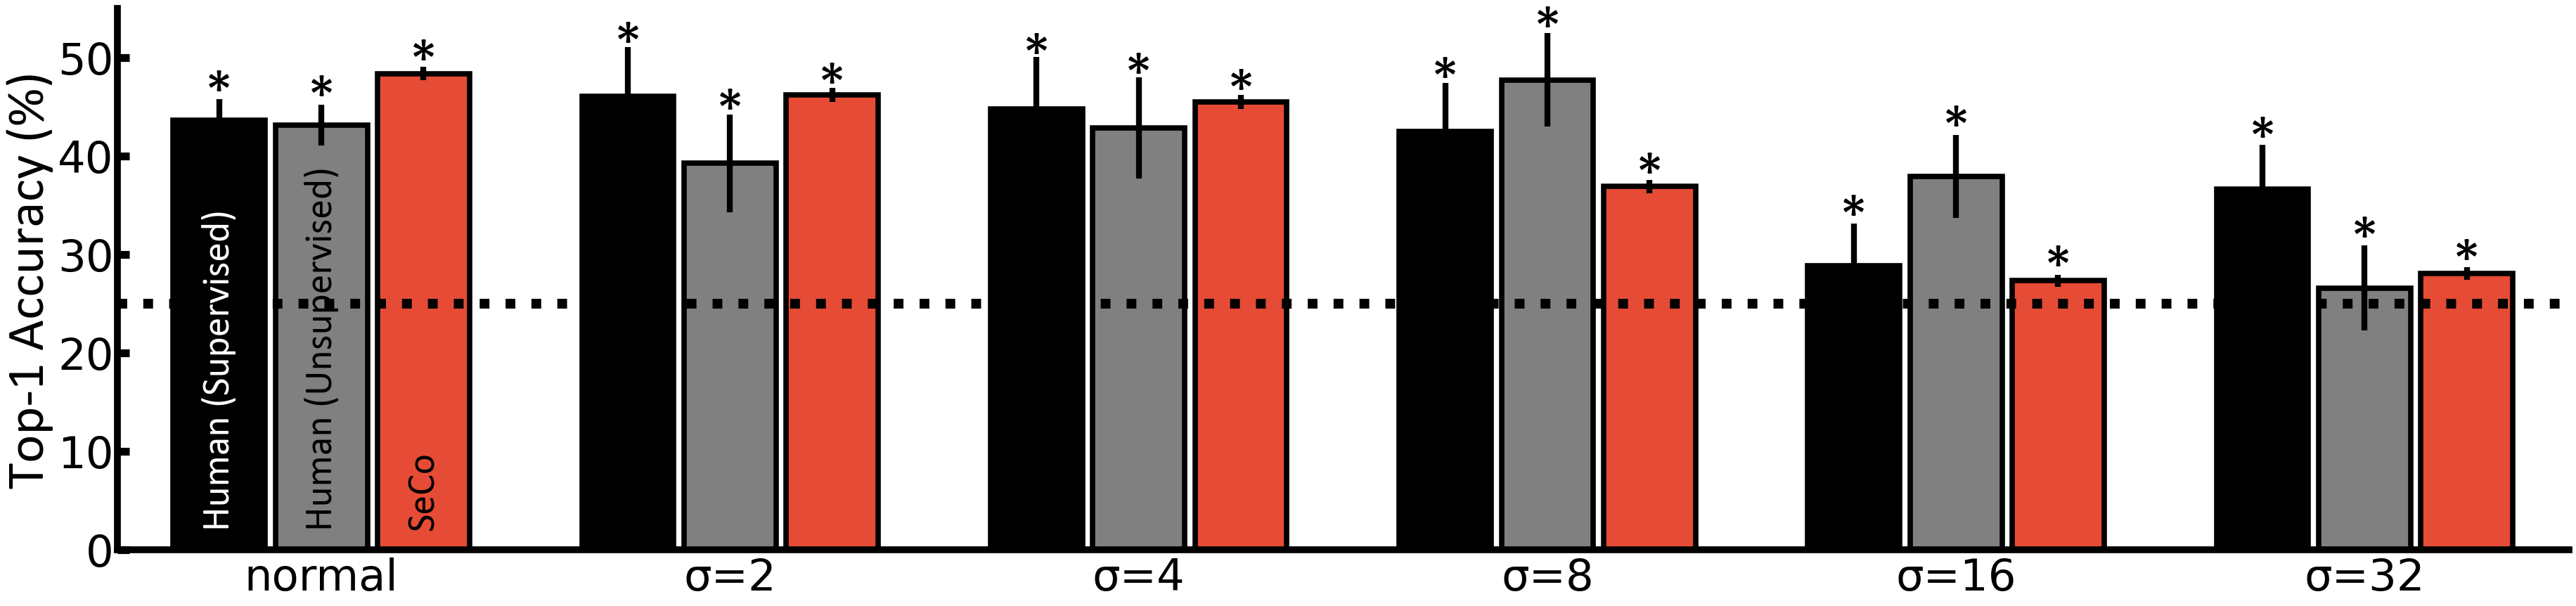

In [14]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

model_names = ['seco']

fig, ax = plt.subplots(1, 1,figsize=(45,10))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

# fig, ax = plt.subplots(1, 1,figsize=(12,4))
conditions = ['normal']+['blur{}'.format(i) for i in range(1,6)]
xtick_rename = ['normal'] + ['σ={}'.format(_) for _ in [2,4,8,16,32]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, yerr, colors, labels = [], [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in human_res_names + model_names:
        ys.append(model_results_avg[model][cond])
        yerr.append(model_error_bars_all[model][cond])

    xs.extend([i*4+_ for _ in range(3)])
    xtick_ori.append(i*4+1)
    colors.extend(["black","gray","#e64b35"])
    labels.extend(["Human (Supervised)", "Human (Unsupervised)", "SeCo"])
    
plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=10)
# plt.plot([-7.5]+xs+[xs[-1]+7.5], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=12)

# bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
bars =plt.bar(xs,ys, width=0.9,linewidth=5.5,edgecolor='black',color=colors, label=labels)
plt.errorbar(xs,ys, yerr,elinewidth=6,fmt="o", color='black')

# plt.suptitle('blurred context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
# plt.ylabel('accuracy', fontsize=15)
# plt.yticks(fontsize=15)
# plt.legend(["chance"]+labels[:6],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.25,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
plt.ylabel('Top-1 Accuracy (%)', fontsize=55,weight = 'bold',fontproperties=prop)
# plt.xticks(xs,[],fontsize=15)
plt.yticks([_*0.01 for _ in range(0,55,10)],range(0,55,10),fontsize=45)
plt.xticks(xtick_ori,xtick_rename,fontsize=45)
ax.set_xlim([-1, xs[-1]+1])
ax.set_ylim(0,0.55)
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(7)
    
for i, rect in enumerate(bars):
    height = rect.get_height()
    if i < 2:
        star_height = height
    elif i % 3!=2:
        star_height = height + yerr[i]/2 
    else:
        star_height = height - yerr[i] *2.5

    color = 'white' if i == 0 else 'black'
    if i <= 2:
        plt.text(rect.get_x() + rect.get_width() / 2.0, 0.02, labels[i], color=color, ha='center', va='bottom',rotation='vertical',fontsize=40,fontproperties=prop)
    _ = plt.text(rect.get_x() + rect.get_width() / 2.0, star_height, '*', color='black', ha='center', va='bottom',fontsize=60,fontproperties=prop)

ax.tick_params(axis='y',direction='in', length=12,width=8)

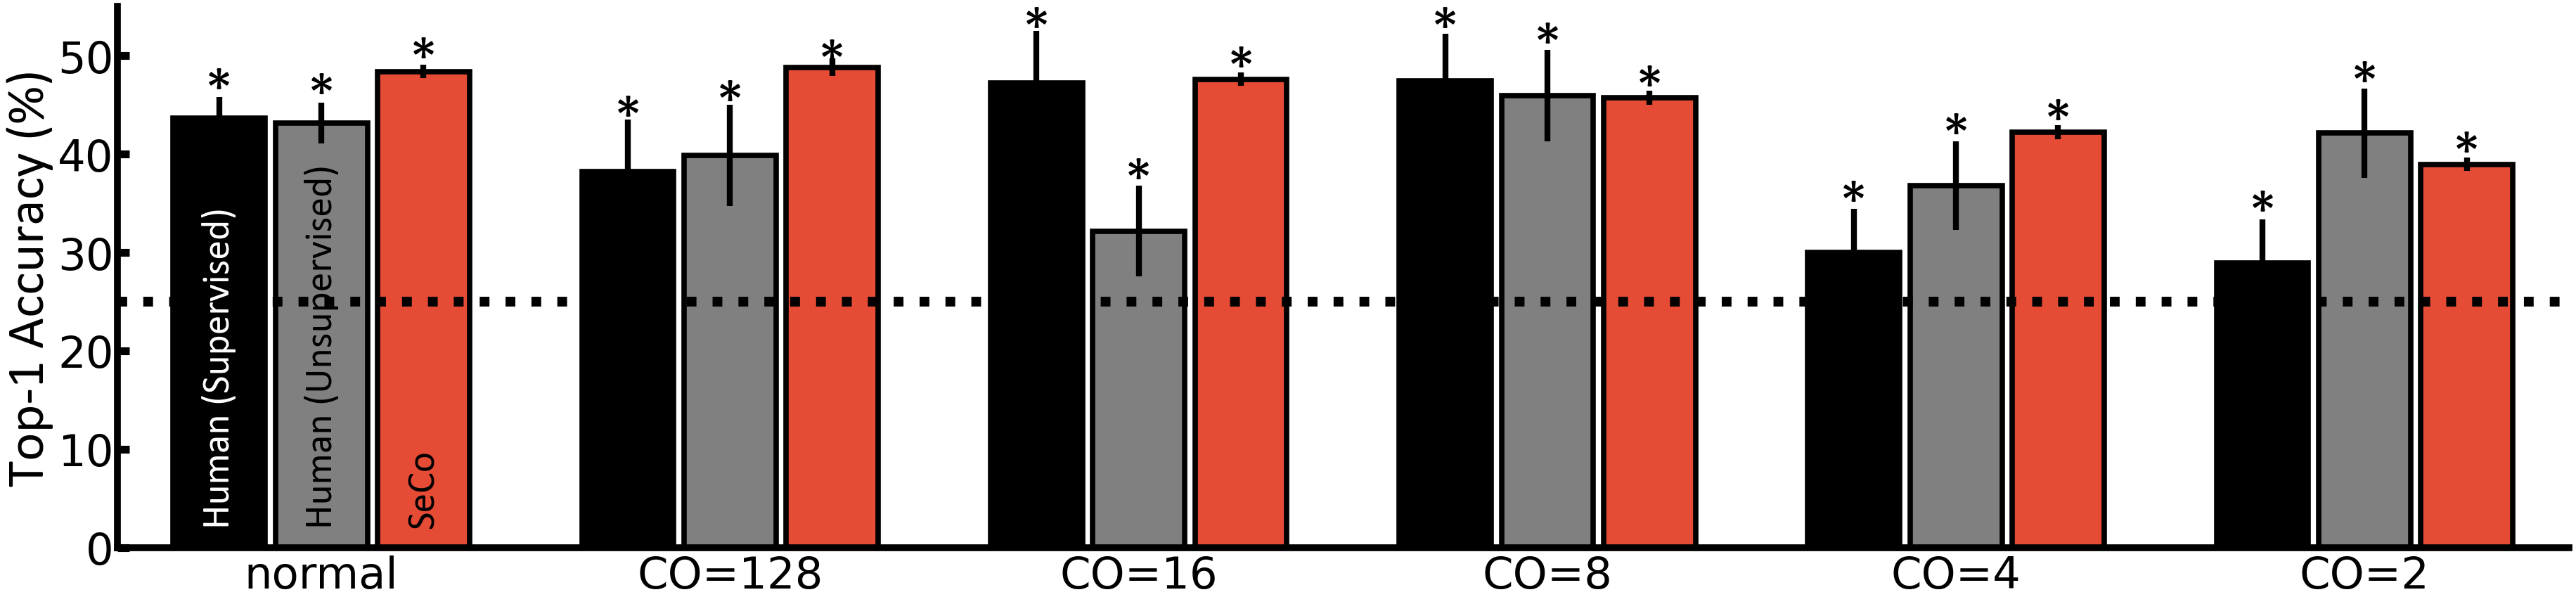

In [15]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

model_names = ['seco']

fig, ax = plt.subplots(1, 1,figsize=(45,10))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

# fig, ax = plt.subplots(1, 1,figsize=(12,4))
conditions = ['normal']+['amount{}'.format(i) for i in range(5,0,-1)]
xtick_rename = ['normal'] + ['CO={}'.format(_) for _ in [128,16,8,4,2]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, yerr, colors, labels = [], [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in human_res_names + model_names:
        ys.append(model_results_avg[model][cond])
        yerr.append(model_error_bars_all[model][cond])
    xs.extend([i*4+_ for _ in range(3)])
    xtick_ori.append(i*4+1)
    colors.extend(["black","gray","#e64b35"])
    labels.extend(["Human (Supervised)", "Human (Unsupervised)", "SeCo"])
    
plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=10)
# plt.plot([-7.5]+xs+[xs[-1]+7.5], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=12)

# bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
bars =plt.bar(xs,ys, width=0.9,linewidth=5.5,edgecolor='black',color=colors, label=labels)
plt.errorbar(xs,ys, yerr,elinewidth=6,fmt="o", color='black')

# plt.suptitle('blurred context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
# plt.ylabel('accuracy', fontsize=15)
# plt.yticks(fontsize=15)
# plt.legend(["chance"]+labels[:6],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.25,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
plt.ylabel('Top-1 Accuracy (%)', fontsize=55,weight = 'bold',fontproperties=prop)
# plt.xticks(xs,[],fontsize=15)
plt.yticks([_*0.01 for _ in range(0,55,10)],range(0,55,10),fontsize=45)
plt.xticks(xtick_ori,xtick_rename,fontsize=45)
ax.set_xlim([-1, xs[-1]+1])
ax.set_ylim(0,0.55)
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(7)
    
for i, rect in enumerate(bars):
    height = rect.get_height()
    if i < 2:
        star_height = height
    elif i % 3!=2:
        star_height = height + yerr[i]/2 
    else:
        star_height = height - yerr[i] *2.5

    color = 'white' if i == 0 else 'black'
    if i <= 2:
        plt.text(rect.get_x() + rect.get_width() / 2.0, 0.02, labels[i], color=color, ha='center', va='bottom',rotation='vertical',fontsize=40,fontproperties=prop)
    _ = plt.text(rect.get_x() + rect.get_width() / 2.0, star_height, '*', color='black', ha='center', va='bottom',fontsize=60,fontproperties=prop)

ax.tick_params(axis='y',direction='in', length=12,width=8)

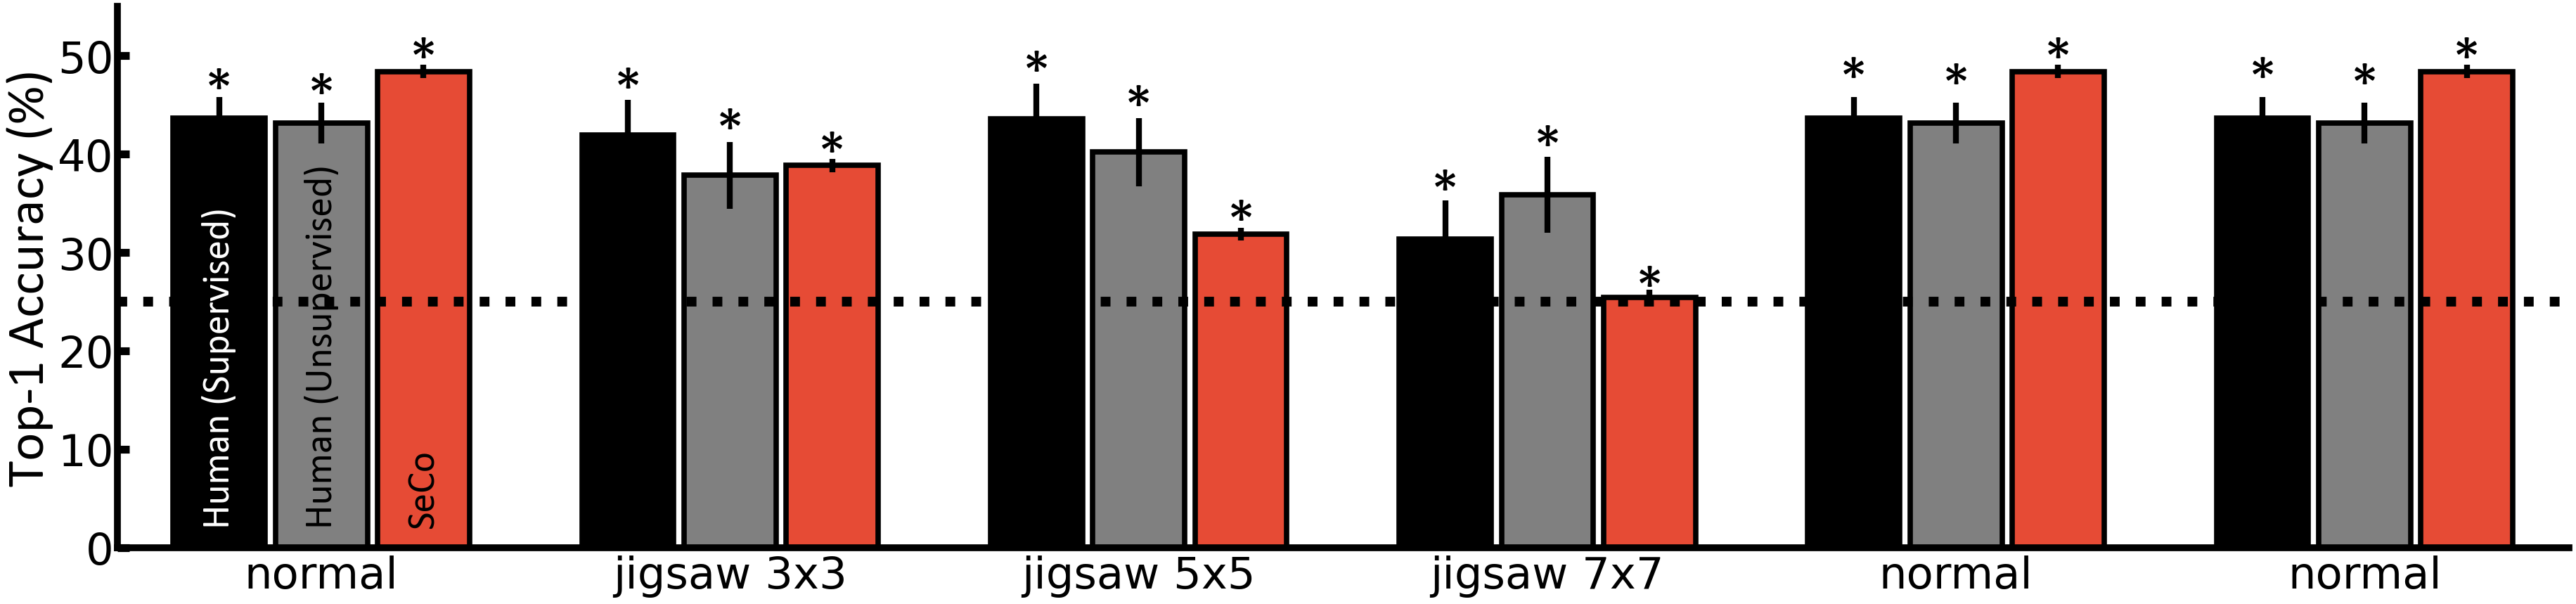

In [16]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

model_names = ['seco']

fig, ax = plt.subplots(1, 1,figsize=(45,10))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

# fig, ax = plt.subplots(1, 1,figsize=(12,4))
conditions = ['normal']+['jigsaw{}'.format(i) for i in range(1,4)] + ['normal']*2
xtick_rename = ['normal'] + ['jigsaw {}x{}'.format(_,_) for _ in [3,5,7]]+ ['normal']*2
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, yerr, colors, labels = [], [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in human_res_names + model_names:
        ys.append(model_results_avg[model][cond])
        yerr.append(model_error_bars_all[model][cond])
    xs.extend([i*4+_ for _ in range(3)])
    xtick_ori.append(i*4+1)
    colors.extend(["black","gray","#e64b35"])
    labels.extend(["Human (Supervised)", "Human (Unsupervised)", "SeCo"])

plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=10)
# plt.plot([-7.5]+xs+[xs[-1]+7.5], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=12)

# bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
bars =plt.bar(xs,ys, width=0.9,linewidth=5.5,edgecolor='black',color=colors, label=labels)
plt.errorbar(xs,ys, yerr,elinewidth=6,fmt="o", color='black')

# plt.suptitle('blurred context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
# plt.ylabel('accuracy', fontsize=15)
# plt.yticks(fontsize=15)
# plt.legend(["chance"]+labels[:6],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.25,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
plt.ylabel('Top-1 Accuracy (%)', fontsize=55,weight = 'bold',fontproperties=prop)
# plt.xticks(xs,[],fontsize=15)
# plt.yticks(fontsize=45)
plt.yticks([_*0.01 for _ in range(0,55,10)],range(0,55,10),fontsize=45)
plt.xticks(xtick_ori,xtick_rename,fontsize=45)
ax.set_xlim([-1, xs[-1]+1])
ax.set_ylim(0,0.55)
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(7)
    
for i, rect in enumerate(bars):
    height = rect.get_height()
    if i < 2:
        star_height = height
    elif i % 3!=2:
        star_height = height + yerr[i]/2 
    else:
        star_height = height - yerr[i] *2.5

    color = 'white' if i == 0 else 'black'
    if i <= 2:
        plt.text(rect.get_x() + rect.get_width() / 2.0, 0.02, labels[i], color=color, ha='center', va='bottom',rotation='vertical',fontsize=40,fontproperties=prop)
    _ = plt.text(rect.get_x() + rect.get_width() / 2.0, star_height, '*', color='black', ha='center', va='bottom',fontsize=60,fontproperties=prop)

ax.tick_params(axis='y',direction='in', length=12,width=8)

In [13]:
model_results_avg, model_error_bars_all

({'vicreg': {'normal': 0.4401866004783911,
   'jigsaw1': 0.31093012859648655,
   'jigsaw2': 0.2791020831337299,
   'jigsaw3': 0.3110024449184554,
   'blur1': 0.43740628334630915,
   'blur2': 0.4260708226434637,
   'blur3': 0.39455050083817444,
   'blur4': 0.27860096676434376,
   'blur5': 0.22520135690768558,
   'amount1': 0.3415080679034045,
   'amount2': 0.3665093187308648,
   'amount3': 0.433968617472675,
   'amount4': 0.4505245886818958,
   'amount5': 0.505734968043509},
  'seco': {'normal': 0.48412211858285426,
   'jigsaw1': 0.38842955388960954,
   'jigsaw2': 0.3186125438501183,
   'jigsaw3': 0.25476411535407845,
   'blur1': 0.4621134861542361,
   'blur2': 0.4550601787318547,
   'blur3': 0.3691499112580251,
   'blur4': 0.27353622667727623,
   'blur5': 0.2808759957188513,
   'amount1': 0.389538192754972,
   'amount2': 0.42234860713973327,
   'amount3': 0.4571549980781213,
   'amount4': 0.4762651013570891,
   'amount5': 0.4883054590509051},
  'dino': {'normal': 0.3746268677026518,
  

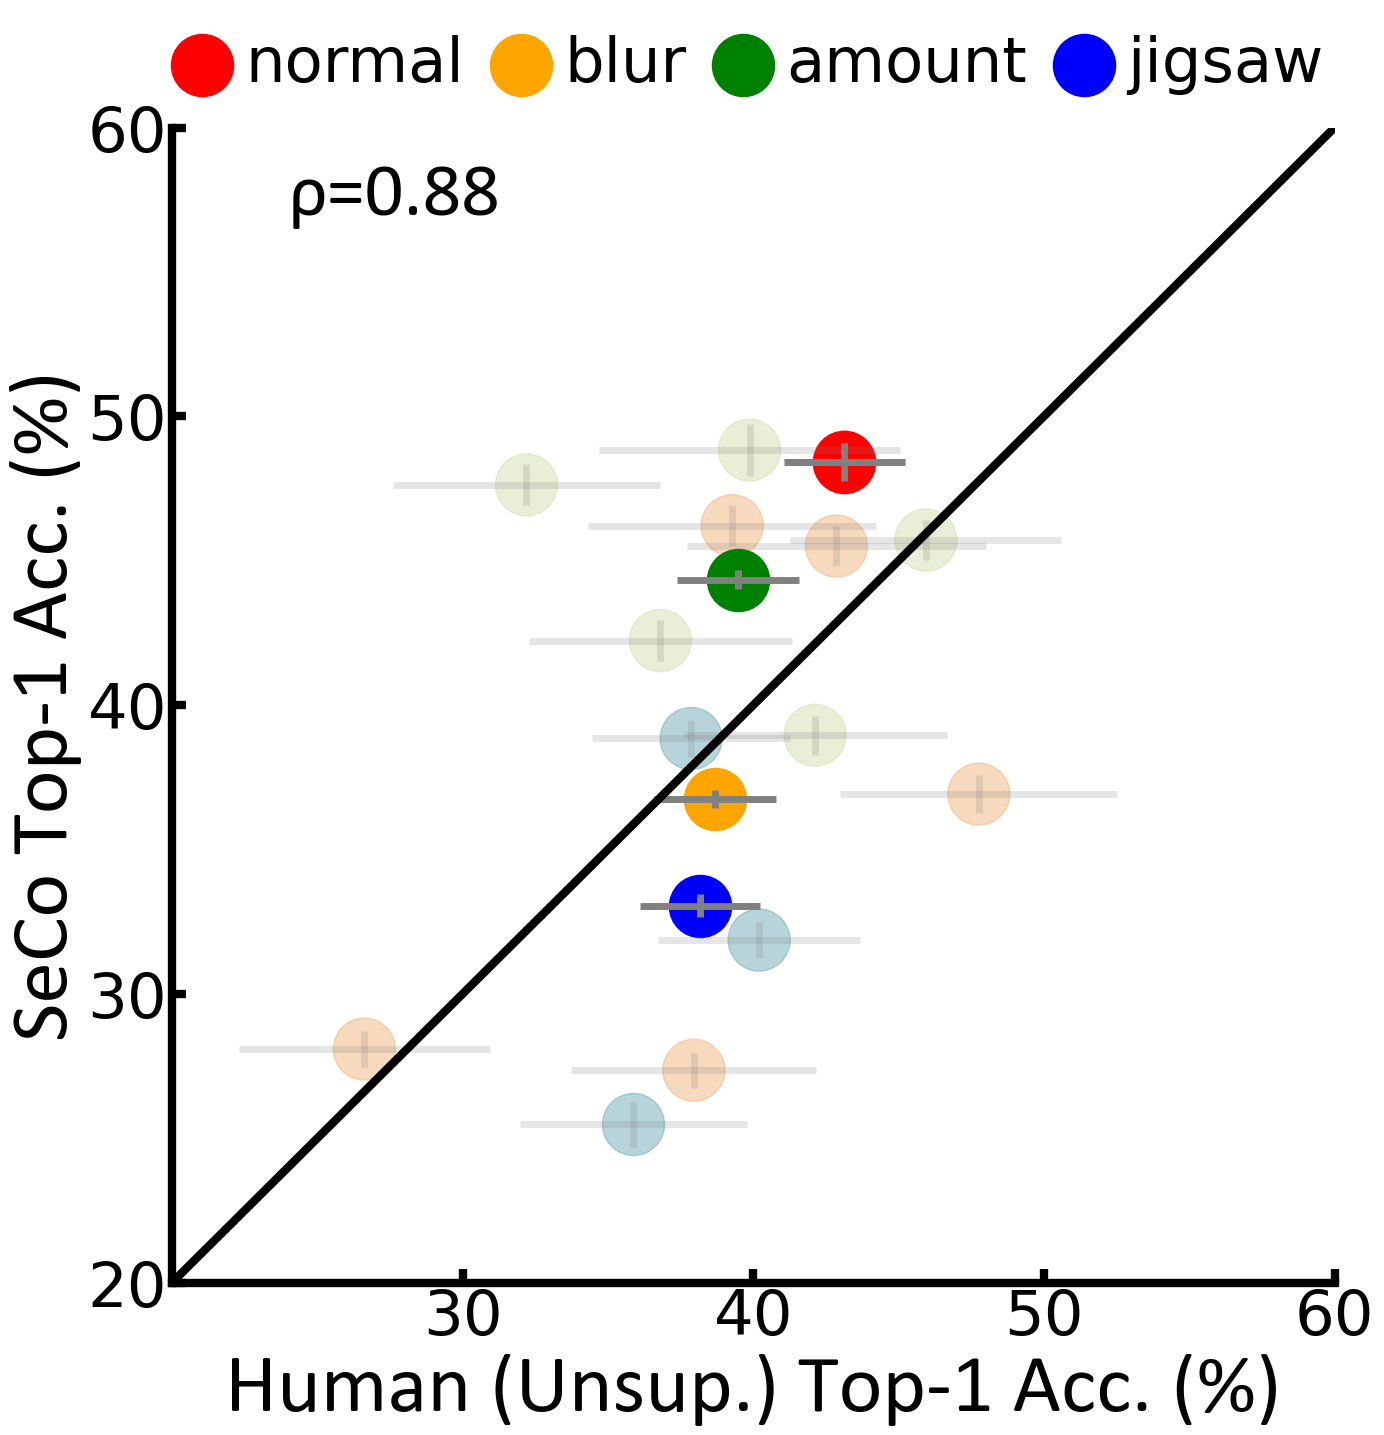

In [61]:
# model vs human

import matplotlib
from scipy.stats import pearsonr


matplotlib.rcParams.update(matplotlib.rcParamsDefault)
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')
# ['microwave','keyboard','pillow','poundcake']
# color_map = ['#C75C64','#F0B57D', '#D3E1AE', '#71ABB6','#A360AD']
color_map = {
'norma':'#C75C64',
'blur':'#F0B57D',
'amount':'#D3E1AE',
'jigsaw':'#71ABB6'}

xs, ys, colors, labels= [], [], [], [] # x-normal, y-blur
xerr, yerr = [], []
# for k, (acc,error) in acc_unsup_coarse.items():
# #     if 'normal' not in k or len(results_grp_by_case_unsup_coarse[k]) < 10:
# #         continue
#     xs.append(acc)
#     ys.append(model_acc_unsup_coarse[k.replace('test_human','test')][0])
#     xerr.append(error)
#     yerr.append(model_acc_unsup_coarse[k.replace('test_human','test')][1])
# #     print(k, xs[-1],ys[-1])
#     colors.append(color_map[k.split('_')[-1]])
# #     labels.append(k.split('_')[0])
# #     print(error, model_acc_unsup_coarse[k.replace('normal','blur')][1])

for k, acc in model_results_avg['seco'].items():
    xs.append(model_results_avg['human_unsup'][k])
    ys.append(acc)
    xerr.append(model_error_bars_all['human_unsup'][k])

    yerr.append(model_error_bars_all['seco'][k])
    colors.append(color_map[k[0:-1]])
    


pool_xs = [0.43134662045060657,0.3868521897810219,0.3947047101449275, 0.38157548845470696]
pool_ys = [0.48412211858285426,0.36746324301947214,0.4433852980136768,0.3305649384014777]
pool_colors =  ['#C75C64', '#F0B57D', '#D3E1AE', '#71ABB6']
pool_colors = ['red','orange','green','blue']
pool_xerr = [0.02069862396773713,0.02101462683610344,0.02099664423020066,0.02065887071174324]
pool_yerr =  [0.006575286218037771,0.0030038965108799584,0.003255841692848849,0.003916667945606736]

ax.errorbar(xs,ys, xerr=xerr, yerr=yerr,elinewidth=5,fmt="none", color='gray',alpha=0.2)
ax.scatter(xs,ys,s=2000,c=colors,alpha=0.5)

ax.errorbar(pool_xs,pool_ys, xerr=pool_xerr, yerr=pool_yerr,elinewidth=5,fmt="none", color='gray',alpha=1.0)
for i in range(4):
    ax.scatter(pool_xs[i],pool_ys[i],s=2000,c=pool_colors[i],alpha=1.0,label=['normal','blur','amount','jigsaw'][i])


ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=6)

trial_coor = round(pearsonr(xs,ys)[0],2)
pool_coor = round(pearsonr(pool_xs,pool_ys)[0],2)
plt.text(0.24,0.57,"ρ={}".format(pool_coor),fontproperties=prop,size=55)
# plt.text(-0.05,1.0,"ρ(trial)={}".format(trial_coor),fontproperties=prop,size=40)
plt.ylabel('SeCo Top-1 Acc. (%)', fontsize=60,weight = 'bold',fontproperties=prop)
plt.xlabel('Human (Unsup.) Top-1 Acc. (%)', fontsize=60,weight = 'bold',fontproperties=prop)


plt.xticks([_*0.1 for _ in range(3,7)],[_*10 for _ in range(3,7)],fontsize=45)
plt.yticks([_*0.1 for _ in range(2,7)],[_*10 for _ in range(2,7)],fontsize=45)

# plt.xticks(fontsize=30)
# plt.yticks(fontsize=30)
ax.set_xlim([0.2,0.6])
ax.set_ylim([0.2,0.6])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(6)
_ = ax.legend(loc='lower center',ncols=9, bbox_to_anchor=(0,0.98,1,1),prop={'size': 45},frameon=False, columnspacing=0.6, handlelength=0.6, handletextpad=0.4)

ax.tick_params(axis='y',direction='in', length=10,width=6)
ax.tick_params(axis='x',direction='in', length=10,width=6)

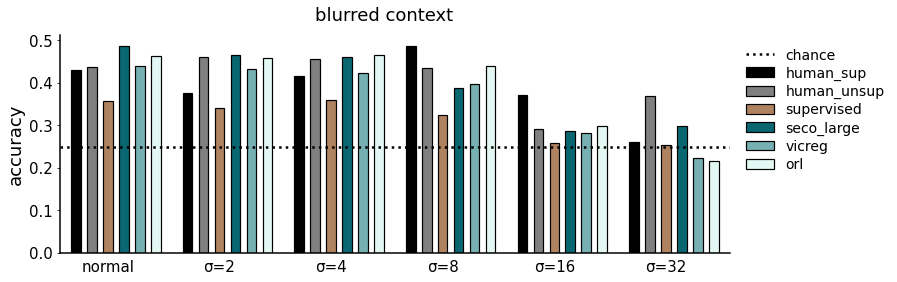

In [13]:

fig, ax = plt.subplots(1, 1,figsize=(12,4))
conditions = ['normal']+['blur{}'.format(i) for i in range(1,6)]
xtick_rename = ['normal'] + ['σ={}'.format(_) for _ in [2,4,8,16,32]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, colors, labels = [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in human_res_names + model_names:
        ys.append(model_results_avg[model][cond])
    xs.extend([i*7+_ for _ in range(6)])
    xtick_ori.append(i*7+2)
    colors.extend(["black","gray","#AF8260","#096771","#76B0B2","#E3F8F3"])
    labels.extend(human_res_names + model_names)
    
plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=2.5)
bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
plt.suptitle('blurred context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
plt.ylabel('accuracy', fontsize=18)
plt.xticks(xtick_ori,xtick_rename,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(["chance"]+labels[:6],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.25,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
ax.set_xlim([-1, xs[-1]+1])
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (36,) and arg 1 with shape (60,).

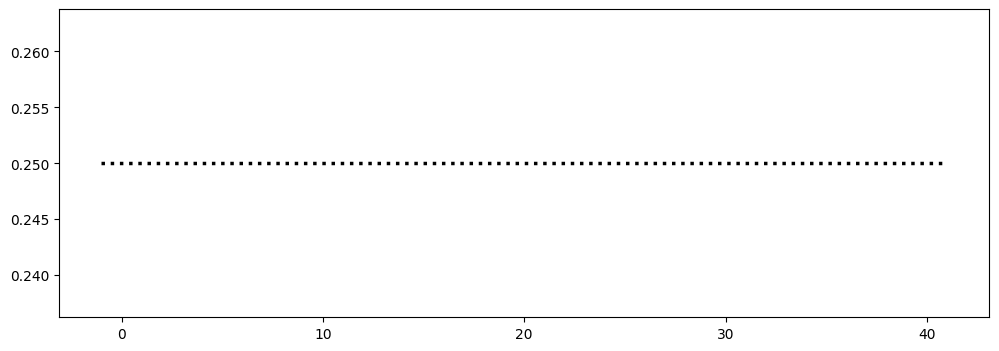

In [38]:
fig, ax = plt.subplots(1, 1,figsize=(12,4))
conditions = ['normal']+['amount{}'.format(i) for i in range(5,0,-1)]
xtick_rename = ['normal'] + ['CO={}'.format(_) for _ in [128,16,8,4,2]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, colors, labels = [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in human_res_names + model_names:
        ys.append(model_results_avg[model][cond])
    xs.extend([i*7+_ for _ in range(6)])
    xtick_ori.append(i*7+2)
    colors.extend(["black","gray","#AF8260","#096771","#76B0B2","#E3F8F3"])
    labels.extend(human_res_names + model_names)

plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=2.5)
bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
plt.suptitle('less context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
plt.ylabel('accuracy', fontsize=18)
plt.xticks(xtick_ori,xtick_rename,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(["chance"]+labels[:6],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.25,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
ax.set_xlim([-1, xs[-1]+1])
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)


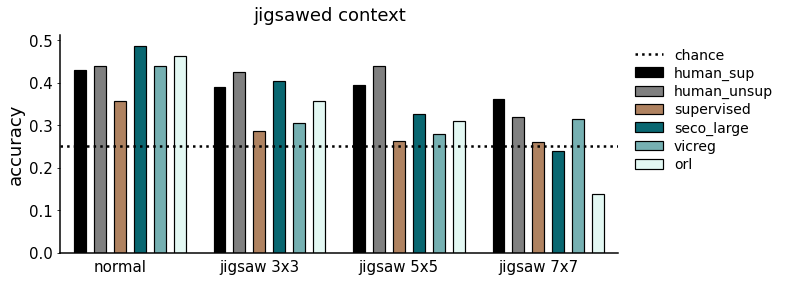

In [15]:
fig, ax = plt.subplots(1, 1,figsize=(10,4))
conditions = ['normal']+['jigsaw{}'.format(i) for i in range(1,4)]
xtick_rename = ['normal'] + ['jigsaw {}x{}'.format(_,_) for _ in [3,5,7]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, colors, labels = [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in human_res_names + model_names:
        ys.append(model_results_avg[model][cond])
    xs.extend([i*7+_ for _ in range(6)])
    xtick_ori.append(i*7+2)
    colors.extend(["black","gray","#AF8260","#096771","#76B0B2","#E3F8F3"])
    labels.extend(human_res_names + model_names)

plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=2.5)
bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
plt.suptitle('jigsawed context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
plt.ylabel('accuracy', fontsize=18)
plt.xticks(xtick_ori,xtick_rename,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(["chance"]+labels[:6],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.3,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
ax.set_xlim([-1, xs[-1]+1])
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
